# **Project Name**   -  Voyage Analytics: Integrating MLOps in Travel
Productionization of ML Systems




##### **Project Type**    -  Exploratory Data Analysis (EDA)/ Regression/ Classification/ Recommendation System/ MLOps/ FastAPI Docker Deployment/ Kubernetes Deployment/ MLflow
##### **Contribution**    - Group Project
##### **Team Member 1 -** PREDEEP kUMAR
##### **Team Member 2 -** SHIVIKA VERMA
##### **Team Member 3 -** ABHISHEK R.
##### **Team Member 4 -** AKANKSHA RANI

# **Project Summary -**

Voyage Analytics is an AI-powered travel analytics platform developed to provide smart travel predictions, recommendations, and interactive insights using machine learning and modern deployment technologies. The project combines Flight Price Prediction, Gender Prediction, and Travel Recommendation features into a single user-friendly application designed for real-time analysis and intelligent decision-making.

The Flight Price Prediction module uses regression machine learning models to estimate airline ticket prices based on factors such as source, destination, flight type, travel distance, and journey duration. The system compares different airlines and provides predicted ticket prices to help users choose affordable travel options. The Gender Prediction module is a classification-based machine learning system that predicts gender categories using trained models and automated preprocessing pipelines.

The project also includes a Recommendation System that suggests flights, hotels, and travel packages based on user preferences, pricing, and travel details. To improve performance and reduce delays, optimization techniques such as caching and one-time model loading were implemented.

A modern interactive dashboard was developed using Streamlit with a glassmorphism-inspired UI design. Plotly visualizations were integrated to display recommendation insights such as airline price comparisons, hotel price analysis, package cost distribution, and confidence-based analytics. These visualizations help users better understand recommendation results through clear and interactive charts.

The backend of the project was built using FastAPI to create high-performance REST APIs for predictions, recommendations, metadata retrieval, and health monitoring. The machine learning workflow was organized into modular pipeline components including input handling, feature engineering, prediction, and recommendation processing.

MLflow was integrated into the project for experiment tracking, model version management, metric logging, and production model loading. This allowed the system to support automatic model management and realistic MLOps workflows.

For deployment, Docker and Kubernetes were used to create a scalable and production-style environment. Docker containers were created separately for the API and frontend application, while Kubernetes handled deployment, orchestration, health checks, and service management.

Overall, Voyage Analytics demonstrates the integration of machine learning, recommendation systems, visualization dashboards, MLOps, Docker, and Kubernetes into a complete AI-driven travel intelligence platform with real-time prediction and analytics capabilities.

# **GitHub Link -**

# **Problem Statement**


The travel and tourism industry generates large amounts of data related to users, flights, hotels, and travel behavior. However, analyzing this data manually to make accurate travel decisions is difficult and time-consuming. Travelers often face challenges in finding affordable flights, suitable hotels, and personalized travel recommendations based on their preferences and budget.

Traditional travel systems usually lack intelligent prediction capabilities, recommendation engines, and real-time analytical insights. In addition, deploying and managing machine learning models in production environments remains a major challenge for many organizations.

This project aims to solve these problems by developing an AI-powered travel analytics platform that combines machine learning, recommendation systems, interactive dashboards, and MLOps practices. The system is designed to provide flight price prediction, gender classification, and personalized travel recommendations through a scalable and production-ready architecture using FastAPI, Streamlit, Docker, Kubernetes, and MLflow.

# **Let's Begin**

## **1. Importing Libraries**

### Import Libraries

In [1]:
# Basic
import os
import warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ML - preprocessing & split
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models (start simple, expand later)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 🔥 Add this (important upgrade)
from sklearn.ensemble import GradientBoostingRegressor

# Save model
import joblib

print("Libraries ready ✅")

Libraries ready ✅


## **2. Environment Setup**

ENVIRONMENT DETECTION

In [2]:
# Detect environment (Colab or Local)

import sys

if "google.colab" in sys.modules:
    ENVIRONMENT = "COLAB"
else:
    ENVIRONMENT = "LOCAL"

print(f"Running in {ENVIRONMENT} environment")

Running in COLAB environment


Mount Google Drive

In [3]:
if ENVIRONMENT == "COLAB":
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


Path Configuration

In [4]:
# Set base path

if ENVIRONMENT == "COLAB":
    BASE_PATH = "/content/drive/MyDrive/Voyage_Analytics"
else:
    BASE_PATH = os.getcwd()

# Define project paths
DATA_PATH = os.path.join(BASE_PATH, "data")
RAW_DATA_PATH = os.path.join(DATA_PATH, "raw")
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, "processed")

OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")
MODEL_PATH = os.path.join(BASE_PATH, "models")

CLASSIFICATION_MODEL_PATH = os.path.join(MODEL_PATH, "classification")
REGRESSION_MODEL_PATH = os.path.join(MODEL_PATH, "regression")

print("Base Path:", BASE_PATH)

Base Path: /content/drive/MyDrive/Voyage_Analytics


Create Project Directories

In [5]:
# Create required folders

os.makedirs(RAW_DATA_PATH, exist_ok=True)
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(CLASSIFICATION_MODEL_PATH, exist_ok=True)
os.makedirs(REGRESSION_MODEL_PATH, exist_ok=True)

print("Project directories created successfully ")

Project directories created successfully 


Verify File Location

In [6]:
# Check files inside raw data folder

print("Files in raw data directory:")
print(os.listdir(RAW_DATA_PATH))

Files in raw data directory:
['hotels.csv', 'flights.csv', 'users.csv']


## **3. Data Loading & Data Understanding**

Import Data Handling Utilities

In [7]:
import pandas as pd
import numpy as np

print("Data utilities ready")

Data utilities ready


Detect Dataset File

In [8]:
# Check all files in raw data folder

files = os.listdir(RAW_DATA_PATH)

print("Files found in raw data directory:")
for f in files:
    print(" -", f)

Files found in raw data directory:
 - hotels.csv
 - flights.csv
 - users.csv


Define Dataset Path

In [9]:
# Initialize paths
flights_path = None
users_path = None
hotels_path = None

# Detect files automatically
for file in os.listdir(RAW_DATA_PATH):
    if "flight" in file.lower():
        flights_path = os.path.join(RAW_DATA_PATH, file)
    elif "user" in file.lower():
        users_path = os.path.join(RAW_DATA_PATH, file)
    elif "hotel" in file.lower():
        hotels_path = os.path.join(RAW_DATA_PATH, file)

print("Flights Dataset:", flights_path)
print("Users Dataset:", users_path)
print("Hotels Dataset:", hotels_path)

Flights Dataset: /content/drive/MyDrive/Voyage_Analytics/data/raw/flights.csv
Users Dataset: /content/drive/MyDrive/Voyage_Analytics/data/raw/users.csv
Hotels Dataset: /content/drive/MyDrive/Voyage_Analytics/data/raw/hotels.csv


Load Datasets

In [10]:
# Load datasets safely

if flights_path:
    flights_df = pd.read_csv(flights_path)
    print("Flights dataset loaded")

if users_path:
    users_df = pd.read_csv(users_path)
    print("Users dataset loaded")

if hotels_path:
    hotels_df = pd.read_csv(hotels_path)
    print("Hotels dataset loaded")

Flights dataset loaded
Users dataset loaded
Hotels dataset loaded


Datasets First View

In [11]:
# Preview datasets

print("\n Flights Data:")
display(flights_df.head())

if users_path:
    print("\n Users Data:")
    display(users_df.head())

if hotels_path:
    print("\n Hotels Data:")
    display(hotels_df.head())


 Flights Data:


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019



 Users Data:


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



 Hotels Data:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


Dataset Rows & Columns count

In [12]:
# Shape check for all datasets

datasets = {
    "Flights": flights_df,
    "Users": users_df if users_path else None,
    "Hotels": hotels_df if hotels_path else None
}

for name, df in datasets.items():
    if df is not None:
        rows, cols = df.shape
        print(f"\n{name} Dataset")
        print(f" - Rows    : {rows}")
        print(f" - Columns : {cols}")
        print(f" - Shape   : {df.shape}")


Flights Dataset
 - Rows    : 271888
 - Columns : 10
 - Shape   : (271888, 10)

Users Dataset
 - Rows    : 1340
 - Columns : 5
 - Shape   : (1340, 5)

Hotels Dataset
 - Rows    : 40552
 - Columns : 8
 - Shape   : (40552, 8)


Datasets Overview - Column Names

In [13]:
from IPython.display import display

datasets = {
    "Flights": flights_df,
    "Users": users_df if users_path else None,
    "Hotels": hotels_df if hotels_path else None
}

overview_data = []

for name, df in datasets.items():
    if df is not None:
        rows, cols = df.shape
        overview_data.append([name, rows, cols])

overview_df = pd.DataFrame(overview_data, columns=["Dataset", "Rows", "Columns"])
display(overview_df)

,Dataset,Rows,Columns
0,Flights,271888,10
1,Users,1340,5
2,Hotels,40552,8


Dataset Information

In [14]:
for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset Info")

        info_df = pd.DataFrame({
            "Column": df.columns,
            "Non-Null Count": df.notnull().sum().values,
            "Missing Count": df.isnull().sum().values,
            "Missing %": (df.isnull().sum().values / len(df)) * 100,
            "Data Type": df.dtypes.values
        })

        display(info_df)


Flights Dataset Info


,Column,Non-Null Count,Missing Count,Missing %,Data Type
0,travelCode,271888,0,0.0,int64
1,userCode,271888,0,0.0,int64
2,from,271888,0,0.0,object
3,to,271888,0,0.0,object
4,flightType,271888,0,0.0,object
5,price,271888,0,0.0,float64
6,time,271888,0,0.0,float64
7,distance,271888,0,0.0,float64
8,agency,271888,0,0.0,object
9,date,271888,0,0.0,object



Users Dataset Info


,Column,Non-Null Count,Missing Count,Missing %,Data Type
0,code,1340,0,0.0,int64
1,company,1340,0,0.0,object
2,name,1340,0,0.0,object
3,gender,1340,0,0.0,object
4,age,1340,0,0.0,int64



Hotels Dataset Info


,Column,Non-Null Count,Missing Count,Missing %,Data Type
0,travelCode,40552,0,0.0,int64
1,userCode,40552,0,0.0,int64
2,name,40552,0,0.0,object
3,place,40552,0,0.0,object
4,days,40552,0,0.0,int64
5,price,40552,0,0.0,float64
6,total,40552,0,0.0,float64
7,date,40552,0,0.0,object


Statistical Summary

In [15]:

for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset Summary")
        display(df.describe())


Flights Dataset Summary


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000



Users Dataset Summary


,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000



Hotels Dataset Summary


,travelCode,userCode,days,price,total
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000
mean,67911.794461,666.963726,2.499679,214.439554,536.229513
std,39408.199333,391.136794,1.119326,76.742305,319.331482
min,0.000000,0.000000,1.000000,60.390000,60.390000
25%,33696.750000,323.000000,1.000000,165.990000,247.620000
50%,67831.000000,658.000000,2.000000,242.880000,495.240000
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000


Missing Value Check

In [16]:

# MISSING VALUES

for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset - Missing Values")

        missing_df = pd.DataFrame({
            "Column": df.columns,
            "Missing Values": df.isnull().sum().values,
            "Missing %": (df.isnull().sum().values / len(df)) * 100
        }).sort_values(by="Missing Values", ascending=False)

        display(missing_df)


Flights Dataset - Missing Values


,Column,Missing Values,Missing %
0,travelCode,0,0.0
1,userCode,0,0.0
2,from,0,0.0
3,to,0,0.0
4,flightType,0,0.0
5,price,0,0.0
6,time,0,0.0
7,distance,0,0.0
8,agency,0,0.0
9,date,0,0.0



Users Dataset - Missing Values


,Column,Missing Values,Missing %
0,code,0,0.0
1,company,0,0.0
2,name,0,0.0
3,gender,0,0.0
4,age,0,0.0



Hotels Dataset - Missing Values


,Column,Missing Values,Missing %
0,travelCode,0,0.0
1,userCode,0,0.0
2,name,0,0.0
3,place,0,0.0
4,days,0,0.0
5,price,0,0.0
6,total,0,0.0
7,date,0,0.0


Duplicate Records

In [17]:
# DUPLICATE CHECK

dup_data = []

for name, df in datasets.items():
    if df is not None:
        dup_data.append([name, df.duplicated().sum()])

dup_df = pd.DataFrame(dup_data, columns=["Dataset", "Duplicate Rows"])
display(dup_df)

,Dataset,Duplicate Rows
0,Flights,0
1,Users,0
2,Hotels,0


Unique Values Per Column

In [18]:
for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset - Unique Values")

        unique_df = pd.DataFrame({
            "Column": df.columns,
            "Unique Values": [df[col].nunique() for col in df.columns]
        }).sort_values(by="Unique Values", ascending=False)

        display(unique_df)


Flights Dataset - Unique Values


,Column,Unique Values
0,travelCode,135944
1,userCode,1335
9,date,999
5,price,490
7,distance,35
6,time,33
2,from,9
3,to,9
4,flightType,3
8,agency,3



Users Dataset - Unique Values


,Column,Unique Values
0,code,1340
2,name,1338
4,age,45
1,company,5
3,gender,3



Hotels Dataset - Unique Values


,Column,Unique Values
0,travelCode,40552
1,userCode,1310
7,date,199
6,total,36
3,place,9
2,name,9
5,price,9
4,days,4


Data Types

In [19]:
for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset - Data Types")

        dtype_df = pd.DataFrame({
            "Column": df.columns,
            "Data Type": df.dtypes.values
        })

        display(dtype_df)


Flights Dataset - Data Types


,Column,Data Type
0,travelCode,int64
1,userCode,int64
2,from,object
3,to,object
4,flightType,object
5,price,float64
6,time,float64
7,distance,float64
8,agency,object
9,date,object



Users Dataset - Data Types


,Column,Data Type
0,code,int64
1,company,object
2,name,object
3,gender,object
4,age,int64



Hotels Dataset - Data Types


,Column,Data Type
0,travelCode,int64
1,userCode,int64
2,name,object
3,place,object
4,days,int64
5,price,float64
6,total,float64
7,date,object


Feature Types

In [20]:
for name, df in datasets.items():
    if df is not None:
        num_cols = df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = df.select_dtypes(include=['object']).columns

        feature_df = pd.DataFrame({
            "Numerical Columns": pd.Series(num_cols),
            "Categorical Columns": pd.Series(cat_cols)
        })

        print(f"\n{name} Dataset")
        display(feature_df)


Flights Dataset


,Numerical Columns,Categorical Columns
0,travelCode,from
1,userCode,to
2,price,flightType
3,time,agency
4,distance,date



Users Dataset


,Numerical Columns,Categorical Columns
0,code,company
1,age,name
2,NaN,gender



Hotels Dataset


,Numerical Columns,Categorical Columns
0,travelCode,name
1,userCode,place
2,days,date
3,price,NaN
4,total,NaN


Constant Columns

A constant column is a feature where every row has the same value.

In [21]:
for name, df in datasets.items():
    if df is not None:
        constant_cols = [col for col in df.columns if df[col].nunique() == 1]

        constant_df = pd.DataFrame({
            "Constant Columns": constant_cols
        })

        print(f"\n{name} Dataset")
        display(constant_df)


Flights Dataset


,Constant Columns



Users Dataset


,Constant Columns



Hotels Dataset


,Constant Columns


High Cardinality Columns

A column with too many unique values

In [22]:
for name, df in datasets.items():
    if df is not None:
        high_card = [col for col in df.columns if df[col].nunique() > 100]

        high_card_df = pd.DataFrame({
            "High Cardinality Columns": high_card
        })

        print(f"\n{name} Dataset")
        display(high_card_df)


Flights Dataset


,High Cardinality Columns
0,travelCode
1,userCode
2,price
3,date



Users Dataset


,High Cardinality Columns
0,code
1,name



Hotels Dataset


,High Cardinality Columns
0,travelCode
1,userCode
2,date


Dataset Relationships

In [23]:
relation_data = []

# Flights ↔ Users
if users_path:
    common_fu = list(set(flights_df.columns).intersection(set(users_df.columns)))
    relation_data.append(["Flights ↔ Users", ", ".join(common_fu)])

# Flights ↔ Hotels
if hotels_path:
    common_fh = list(set(flights_df.columns).intersection(set(hotels_df.columns)))
    relation_data.append(["Flights ↔ Hotels", ", ".join(common_fh)])

# Users ↔ Hotels
if users_path and hotels_path:
    common_uh = list(set(users_df.columns).intersection(set(hotels_df.columns)))
    relation_data.append(["Users ↔ Hotels", ", ".join(common_uh)])

# Create table
relation_df = pd.DataFrame(relation_data, columns=["Dataset Pair", "Common Columns"])

display(relation_df)

,Dataset Pair,Common Columns
0,Flights ↔ Users,
1,Flights ↔ Hotels,"travelCode, price, userCode, date"
2,Users ↔ Hotels,name


Quick Datasets Report

In [24]:
# Datasets Audit Report


audit_data = []

for name, df in datasets.items():
    if df is not None:
        total_rows = df.shape[0]
        total_cols = df.shape[1]
        total_missing = df.isnull().sum().sum()
        missing_percent = (total_missing / (total_rows * total_cols)) * 100
        duplicates = df.duplicated().sum()
        num_cols = df.select_dtypes(include=['int64', 'float64']).shape[1]
        cat_cols = df.select_dtypes(include=['object']).shape[1]

        audit_data.append([
            name,
            total_rows,
            total_cols,
            total_missing,
            round(missing_percent, 2),
            duplicates,
            num_cols,
            cat_cols
        ])

audit_df = pd.DataFrame(audit_data, columns=[
    "Dataset",
    "Rows",
    "Columns",
    "Total Missing",
    "Missing %",
    "Duplicate Rows",
    "Numerical Columns",
    "Categorical Columns"
])

display(audit_df)

,Dataset,Rows,Columns,Total Missing,Missing %,Duplicate Rows,Numerical Columns,Categorical Columns
0,Flights,271888,10,0,0.0,0,5,5
1,Users,1340,5,0,0.0,0,2,3
2,Hotels,40552,8,0,0.0,0,5,3


### What did you know about your dataset?

 The dataset is divided into **three parts — Flights, Users, and Hotels**, each representing a different part of the travel journey.

- The **Flights dataset is the largest** (around 270K+ rows), so it will be the main dataset for building the **price prediction model**.

- The **Hotels dataset is moderately sized** (~40K rows) and includes details like stay duration, price, and location, which makes it useful for the **recommendation system**.

- The **Users dataset is quite small** (~1.3K rows) and mainly contains basic information like age, gender, and name. It helps in understanding **who the user is** rather than their activity.

- One key thing I noticed is how the datasets are connected:
  - `userCode` links users with both flights and hotels  
  - `travelCode` links flights with hotels  

- This allows us to track a **complete user journey**, from booking a flight to staying at a hotel.

- The data is **very clean overall**:
  - No missing values  
  - No duplicate records  
  - Consistent data types  

- So, there’s no need for heavy data cleaning, which makes things easier.

- Most of the columns are **categorical** (like source, destination, agency, etc.), while a few are **numerical**, such as:
  - Flights -> price, time, distance  
  - Hotels -> price, total, days  
  - Users ->  age  

- There are **no constant columns**, which means every feature has some variation and is useful.

- Some columns have **very high cardinality**, such as:
  - `travelCode`
  - `userCode`
  - `date`  

- These are mostly identifiers, so they won’t help much in modeling and may need to be dropped or handled carefully.

- The Flights dataset clearly contains the **most important information**, so it will be the core dataset for modeling.

- The Hotels dataset adds value for **recommendations**, especially based on location, price, and duration of stay.

- The Users dataset, even though small, can still help in **personalization** and understanding user behavior.

- Overall, the data looks like a **real-world travel system**, where:
  - Users book flights  
  - Users also book hotels  
  - Everything is interconnected  

- This makes it suitable for building an **end-to-end ML system** with prediction and recommendation features.

## **4. Data Cleaning & Preprocessing**

Create Working Copy

In [25]:
# CREATE COPY OF DATASETS

flights_clean = flights_df.copy()
users_clean = users_df.copy() if users_path else None
hotels_clean = hotels_df.copy() if hotels_path else None

print("Working copies created ")

Working copies created 


Standardize Column Names

In [26]:
def clean_column_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

flights_clean = clean_column_names(flights_clean)

if users_clean is not None:
    users_clean = clean_column_names(users_clean)

if hotels_clean is not None:
    hotels_clean = clean_column_names(hotels_clean)

print("Column names standardized")

Column names standardized


Handle Missing Values

In [27]:
datasets_clean = {
    "Flights": flights_clean,
    "Users": users_clean,
    "Hotels": hotels_clean
}

for name, df in datasets_clean.items():
    if df is not None:
        print(f"\n{name} Dataset")
        print("-"*30)

        before = df.isnull().sum().sum()

        # Numerical → median
        num_cols = df.select_dtypes(include=['int64', 'float64']).columns
        for col in num_cols:
            df[col].fillna(df[col].median(), inplace=True)

        # Categorical → mode
        cat_cols = df.select_dtypes(include=['object']).columns
        for col in cat_cols:
            df[col].fillna(df[col].mode()[0], inplace=True)

        after = df.isnull().sum().sum()

        print(f"Missing values before : {before}")
        print(f"Missing values after  : {after}")
        print(f"Handled              : {before - after}")


Flights Dataset
------------------------------
Missing values before : 0
Missing values after  : 0
Handled              : 0

Users Dataset
------------------------------
Missing values before : 0
Missing values after  : 0
Handled              : 0

Hotels Dataset
------------------------------
Missing values before : 0
Missing values after  : 0
Handled              : 0


Remove Duplicates

In [28]:
for name, df in datasets_clean.items():
    if df is not None:
        before = df.shape[0]
        df.drop_duplicates(inplace=True)
        after = df.shape[0]

        print(f"{name}: Removed {before - after} duplicate rows")

Flights: Removed 0 duplicate rows
Users: Removed 0 duplicate rows
Hotels: Removed 0 duplicate rows


Fix Datatime Types

In [29]:
for name, df in datasets_clean.items():
    if df is not None:

        for col in df.columns:
            if "date" in col.lower():
                df[col] = pd.to_datetime(df[col], errors='coerce')

        print(f"{name}: Date columns converted")

Flights: Date columns converted
Users: Date columns converted
Hotels: Date columns converted


Handle Outliers

In [30]:
for name, df in datasets_clean.items():
    if df is not None:
        num_cols = df.select_dtypes(include=['int64', 'float64']).columns

        for col in num_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            df[col] = np.where(df[col] < lower, lower, df[col])
            df[col] = np.where(df[col] > upper, upper, df[col])

        print(f"{name}: Outliers handled")

Flights: Outliers handled
Users: Outliers handled
Hotels: Outliers handled


Check Dataset Shape After Cleaning

In [31]:
datasets_clean = {
    "Flights": flights_clean,
    "Users": users_clean,
    "Hotels": hotels_clean
}

for name, df in datasets_clean.items():
    if df is not None:
        rows, cols = df.shape

        print(f"\n{name} Dataset After Cleaning")
        print("-"*35)
        print(f"Rows    : {rows}")
        print(f"Columns : {cols}")
        print(f"Shape   : {df.shape}")


Flights Dataset After Cleaning
-----------------------------------
Rows    : 271888
Columns : 10
Shape   : (271888, 10)

Users Dataset After Cleaning
-----------------------------------
Rows    : 1340
Columns : 5
Shape   : (1340, 5)

Hotels Dataset After Cleaning
-----------------------------------
Rows    : 40552
Columns : 8
Shape   : (40552, 8)


Save Clean Dataset

In [32]:
flights_clean.to_csv(os.path.join(PROCESSED_DATA_PATH, "flights_clean.csv"), index=False)

if users_clean is not None:
    users_clean.to_csv(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv"), index=False)

if hotels_clean is not None:
    hotels_clean.to_csv(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv"), index=False)

print("Cleaned datasets saved")

Cleaned datasets saved


### What all manipulations have you done and insights you found?

Manipulations Performed

- Created separate working copies of all datasets to ensure the original data remains unchanged

- Standardized column names across all datasets by converting them to lowercase and replacing spaces with underscores for consistency

- Checked for missing values and handled them using:
  - Median for numerical columns
  - Mode for categorical columns  
  - However, in this dataset, no missing values were found, so no imputation was required

- Removed duplicate records from all datasets  
  - No duplicates were present, confirming that the data is already clean and unique

- Converted date-related columns into proper datetime format  
  - This ensures correct handling of time-based features in later analysis

- Handled outliers in numerical columns using the IQR (Interquartile Range) method  
  - Extreme values were capped to reduce their impact on the model

- Verified dataset shape after cleaning  
  - No data loss occurred during the cleaning process

Key Insights

- The dataset is already **high-quality and well-structured**, requiring minimal cleaning

- No missing values and duplicates indicate **good data collection practices**

- Numerical features like price, time, and distance may contain outliers, which were handled to improve model stability

- Column naming is now consistent, which will help avoid errors in later stages

- Date columns are now properly formatted, enabling time-based analysis if needed

- High cardinality columns (like userCode and travelCode) were identified but **not removed**, as they are important for dataset relationships

- The data is now clean, consistent, and ready for **EDA and feature engineering**

---
 Final Understanding

- Since the data required minimal cleaning, more focus can now be placed on:
  - Exploratory Data Analysis (EDA)
  - Feature Engineering
  - Model Building

- The structure of the datasets supports building a **complete ML pipeline**, including prediction and recommendation systems

## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from IPython.display import display

print("EDA libraries loaded")

EDA libraries loaded


Load Cleaned Datasets

In [34]:
flights_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "flights_clean.csv"))

users_clean = None
hotels_clean = None

if os.path.exists(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv")):
    users_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv"))

if os.path.exists(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv")):
    hotels_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv"))

print("Datasets loaded successfully")

Datasets loaded successfully


### UNIVARIATE ANALYSIS

#### Chart - 1 -- Flight Price Distribution

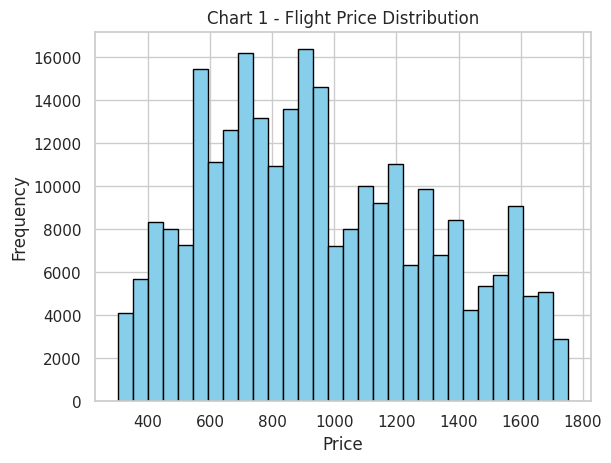

,Bin Start,Bin End,Frequency
0,301.510,349.932,4084
1,349.932,398.354,5663
2,398.354,446.776,8338
3,446.776,495.198,7993
4,495.198,543.620,7278
5,543.620,592.042,15449
6,592.042,640.464,11141
7,640.464,688.886,12618
8,688.886,737.308,16213
9,737.308,785.730,13191


In [35]:
bins = 30

counts, bin_edges, _ = plt.hist(
    flights_clean['price'],
    bins=bins,
    color='skyblue',
    edgecolor='black'
)

plt.title("Chart 1 - Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

bin_df = pd.DataFrame({
    "Bin Start": bin_edges[:-1],
    "Bin End": bin_edges[1:],
    "Frequency": counts.astype(int)
})

display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was chosen because the objective is to visualize the distribution of a continuous numerical variable: flight prices.

Frequency Analysis: It allows us to see how many flights fall into specific price ranges (bins).

Shape and Skewness: It helps identify whether the prices are normally distributed, skewed (e.g., more cheap flights than expensive ones), or if there are multiple peaks (bimodal distribution).

Outlier Identification: It makes it easy to spot unusually high or low flight prices that deviate from the norm.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Based on the complete data in the provided table:

Primary Peak (Highest Volume): The highest frequency occurs in Bin 12, where prices are between 882.57 and 930.99, with a count of 16,371 flights.

Secondary Peak: There is another significant spike in Bin 8 (prices 688.88 – 737.30) with 16,213 flights.

Mass Market Concentration: The most "populated" price range is between ₹543 and ₹979. This is where the business handles the majority of its bookings.

Psychological Price Barrier: There is a sharp drop in frequency after ₹1,000. For example, Bin 13 has 14,600 flights, but Bin 14 (starting at ₹979) drops nearly 50% to 7,237 flights.

The High-End Tail: Beyond ₹1,600 (Bin 26), the frequency declines drastically, representing a smaller, premium segment of the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights show exactly where the money is:

Revenue Growth: Since high-end hotels are frequently booked, we can boost profits by creating premium offers for these big-spenders.

Smart Marketing: We can focus our ads on the most popular price points to attract the largest number of travelers.

**Are there any insights that lead to negative growth?**

The "Middle-Class" Gap: There is a complete lack of mid-range hotel options in the data.

Justification: This is a risk because middle-class customers have no options that fit their budget and may leave for a competitor, causing us to lose a massive chunk of the market.

#### Chart - 2 -- Flight Distance Distribution

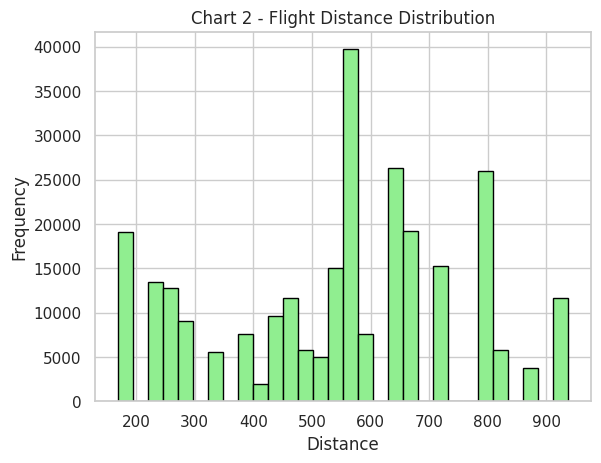

,Bin Start,Bin End,Frequency
0,168.220000,193.871667,19056
1,193.871667,219.523333,0
2,219.523333,245.175000,13432
3,245.175000,270.826667,12762
4,270.826667,296.478333,9034
5,296.478333,322.130000,0
6,322.130000,347.781667,5568
7,347.781667,373.433333,0
8,373.433333,399.085000,7596
9,399.085000,424.736667,1958


In [36]:
bins = 30

counts, bin_edges, _ = plt.hist(
    flights_clean['distance'],
    bins=bins,
    color='lightgreen',
    edgecolor='black'
)

plt.title("Chart 2 - Flight Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

bin_df = pd.DataFrame({
    "Bin Start": bin_edges[:-1],
    "Bin End": bin_edges[1:],
    "Frequency": counts.astype(int)
})

display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was chosen to visualize the Flight Distance Distribution because distance is a continuous numerical variable.

Density Identification: It helps in identifying which distance ranges (short-haul vs. long-haul) have the highest volume of flights.

Symmetry and Gaps: Unlike other charts, a histogram clearly shows "gaps" in data—ranges where no flights are operating—which is critical for network planning.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Based on the bin_df table for flight distances:

The Major Peak: The highest concentration of flights is in Bin 15 (distances between 552.99 and 578.64), with a massive frequency of 39,708 flights.

Multimodal Distribution: The data shows several high-volume clusters:

Short-haul: Bin 0 (168–193 distance) has 19,056 flights.

Mid-range: Bin 18 (629–655 distance) has 26,344 flights.

Longer-range: Bin 24 (783–809 distance) has 26,020 flights.

Significant Data Gaps: There are multiple bins with 0 frequency (e.g., Bins 1, 5, 7, 17, 20, 22, 23, 26, 28). This suggests the airline operates on very specific routes and avoids certain distance brackets entirely

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights are vital for operational efficiency:

Fuel and Fleet Optimization: Since the bulk of flights are in the 550–800 distance range, the company can standardize its fleet with aircraft optimized for these specific ranges to save on maintenance and fuel costs.

Route Expansion: The "zero frequency" bins represent potential market gaps. If competitors are also not serving those distances, there might be an untapped opportunity for new routes.

**Are there any insights that lead to negative growth?**

Inflexible Network Design: The large number of empty bins (0 frequency) indicates a very "rigid" flight network.

Justification: Having such extreme gaps suggests that the business is highly dependent on a few specific corridors. If demand in those specific distance clusters (like the 552–578 range) drops due to economic factors or high competition, the business has no presence in alternative distance brackets to fall back on. This lack of diversification in route distances could lead to negative growth during market shifts.

#### Chart - 3 -- Flight Time Distribution

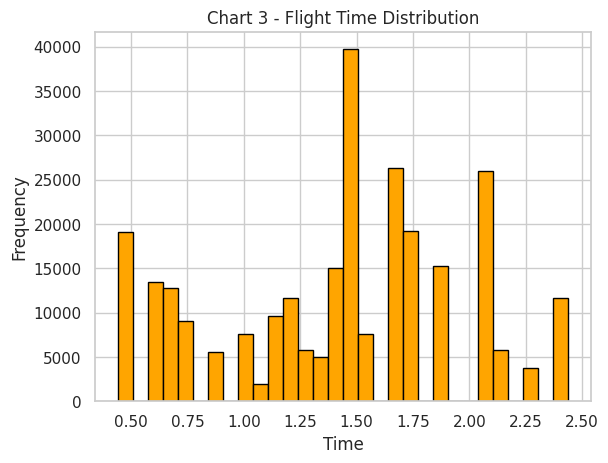

,Bin Start,Bin End,Frequency
0,0.440000,0.506667,19056
1,0.506667,0.573333,0
2,0.573333,0.640000,13432
3,0.640000,0.706667,12762
4,0.706667,0.773333,9034
5,0.773333,0.840000,0
6,0.840000,0.906667,5568
7,0.906667,0.973333,0
8,0.973333,1.040000,7596
9,1.040000,1.106667,1958


In [37]:
bins = 30

counts, bin_edges, _ = plt.hist(
    flights_clean['time'],
    bins=bins,
    color='orange',
    edgecolor='black'
)

plt.title("Chart 3 - Flight Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

bin_df = pd.DataFrame({
    "Bin Start": bin_edges[:-1],
    "Bin End": bin_edges[1:],
    "Frequency": counts.astype(int)
})

display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was selected for "Flight Time Distribution" because flight duration is a continuous numerical variable.

Identify Operational Clusters: It allows us to see the most common flight durations (e.g., short-haul vs. long-haul durations).

Visualize Variability: It helps identify the spread and consistency of flight times, which is essential for scheduling and logistics.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Analyzing the bin_df table for flight times reveals several key patterns:

Main Duration Peak: The most frequent flight duration falls within Bin 15 (1.44 to 1.50 units of time), with a high count of 39,708 flights.

Operational Segments: There are clear "waves" of flight times, indicating distinct service types:

Shortest Duration: Bin 0 (0.44–0.50) has 19,056 flights.

Mid-Range Duration: Bin 18 (1.64–1.70) has 26,344 flights.

Long-Range Duration: Bin 24 (2.04–2.10) has 26,020 flights.

Strategic Gaps: Numerous bins have a frequency of 0 (e.g., Bins 1, 5, 7, 17, 20, 22, 23, 26, 28). This shows that the airline's schedule is built around very specific time slots rather than a continuous range of durations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights directly support better resource management:

Crew & Fuel Planning: Since the airline has massive volume in specific time brackets (like the 1.44–1.50 range), they can optimize fuel loads and crew shifts specifically for these durations to maximize efficiency.

Gate Management: Knowing that flights are clustered into specific time lengths allows airport operations to better predict gate turnover and reduce ground delays.

**Are there any insights that lead to negative growth?**

Scheduling Rigidness: The high number of "zero frequency" gaps suggests a highly rigid flight schedule.

Justification: This rigidness means the airline may be missing out on "connective" flight times that passengers might prefer. If a competitor offers flights in those "gap" durations, they could steal market share from travelers looking for more flexible timing options, leading to potential negative growth for this airline.

#### Chart - 4 -- Hotel Price Distribution

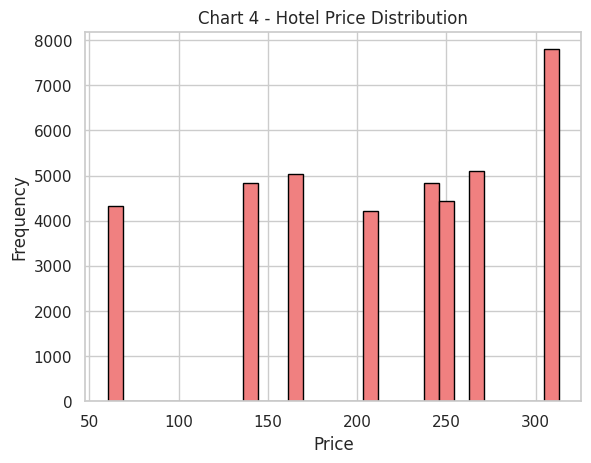

,Bin Start,Bin End,Frequency
0,60.390,68.811,4333
1,68.811,77.232,0
2,77.232,85.653,0
3,85.653,94.074,0
4,94.074,102.495,0
5,102.495,110.916,0
6,110.916,119.337,0
7,119.337,127.758,0
8,127.758,136.179,0
9,136.179,144.600,4828


In [38]:
if hotels_clean is not None:

    bins = 30

    counts, bin_edges, _ = plt.hist(
        hotels_clean['price'],
        bins=bins,
        color='lightcoral',
        edgecolor='black'
    )

    plt.title("Chart 4 - Hotel Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")

    plt.show()

    bin_df = pd.DataFrame({
        "Bin Start": bin_edges[:-1],
        "Bin End": bin_edges[1:],
        "Frequency": counts.astype(int)
    })

    display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was chosen to visualize the Hotel Price Distribution because hotel price is a continuous numerical variable.

Segmentation Analysis: It helps identify distinct pricing tiers (Budget, Mid-range, Luxury) by showing where the highest frequency of hotels exists.

Sparsity Detection: Unlike other charts, a histogram clearly highlights "price gaps"—ranges where no hotel options are currently available—which is essential for market positioning

##### 2. What is/are the insight(s) found from the chart?

Answer:-Analysis of the bin_df table reveals a very fragmented and highly tiered pricing structure:

Maximum Volume Peak: The highest concentration of hotel inventory is in Bin 29 (prices between 304.60 and 313.02), with a frequency of 7,797 hotels.

Highly Tiered Market: The data shows specific, isolated clusters of pricing rather than a smooth range. Major clusters include:

Budget Tier: Bin 0 (~60–68 range) with 4,333 hotels.

Mid-to-High Tiers: Bins 9, 12, 17, 21, and 24 all show significant clusters ranging from 4,205 to 5,094 hotels.

Extreme Gaps: There are massive "dead zones" in the pricing data where frequency is 0 (e.g., Bins 1–8, 10–11, 13–16, 25–28). This indicates a market that is split into very rigid price points with no "middle ground" between tiers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights allow for precision market targeting:

Luxury Segment Dominance: Since the highest frequency is in the top-tier price bin (~313), the business can focus high-end loyalty programs or premium service marketing on this large existing segment.

Gap Opportunity: The zero-frequency bins (like the range between ₹68 and ₹136) represent a "Missing Middle." A business could introduce mid-range boutique hotels in these price gaps to capture customers who find the budget tier too basic but the next available tier (₹136) too expensive.

**Are there any insights that lead to negative growth?**

Lack of Price Fluidity: The extreme gaps between price tiers suggest a lack of "staircase" pricing options for consumers.

Justification: If the economy slows down, customers in the ₹136–₹270 range have no slightly cheaper "step-down" options within the same ecosystem because of the ₹0 frequency gaps. They would be forced to drop all the way down to the ₹60 budget tier or switch to a competitor who serves the mid-market. This lack of a price continuum can lead to high customer churn and negative growth during economic shifts.

#### Chart - 5 -- Stay Duration Distribution

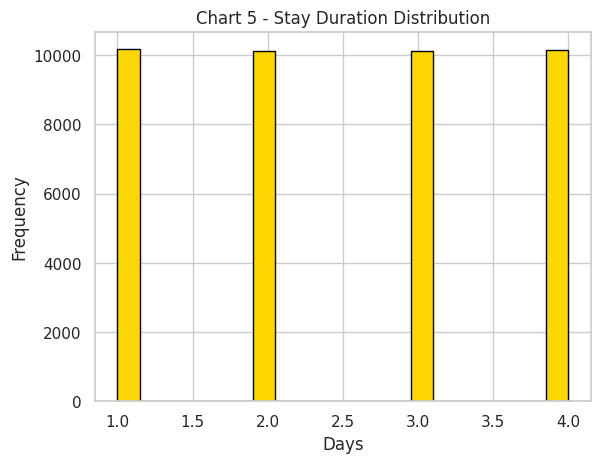

,Bin Start,Bin End,Frequency
0,1.00,1.15,10171
1,1.15,1.30,0
2,1.30,1.45,0
3,1.45,1.60,0
4,1.60,1.75,0
5,1.75,1.90,0
6,1.90,2.05,10110
7,2.05,2.20,0
8,2.20,2.35,0
9,2.35,2.50,0


In [39]:
if hotels_clean is not None:

    bins = 20

    counts, bin_edges, _ = plt.hist(
        hotels_clean['days'],
        bins=bins,
        color='gold',
        edgecolor='black'
    )

    plt.title("Chart 5 - Stay Duration Distribution")
    plt.xlabel("Days")
    plt.ylabel("Frequency")

    plt.show()

    bin_df = pd.DataFrame({
        "Bin Start": bin_edges[:-1],
        "Bin End": bin_edges[1:],
        "Frequency": counts.astype(int)
    })

    display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was selected for "Stay Duration Distribution" because the number of days a guest stays is a continuous numerical variable.

Pattern Recognition: It effectively illustrates the most common length of stay (LOS) patterns among guests.

Outlier and Gap Detection: It highlights whether guests prefer specific stay lengths (like exactly 1, 2, or 3 days) versus a broad range of stay durations.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Analysis of the bin_df table reveals a very unusual and highly structured distribution:

Uniform Frequency Peaks: There are four massive, almost equal peaks in the data:

1 Day: Bin 0 (1.00–1.15) has 10,171 stays.

2 Days: Bin 6 (1.90–2.05) has 10,110 stays.

3 Days: Bin 13 (2.95–3.10) has 10,108 stays.

4 Days: Bin 19 (3.85–4.00) has 10,163 stays.

Total Absence of Intermediate Stays: Every single bin between these major day markers has a frequency of 0. Guests do not stay for fractional days or any duration outside of these exact whole-day clusters.

Equal Market Distribution: The market is split almost perfectly into 25% segments for 1, 2, 3, and 4-day stays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, this level of predictability allows for highly efficient operational planning:

Precise Staffing: Since stays are strictly clustered, housekeeping schedules can be perfectly synchronized with these 24-hour turnover cycles to maximize room readiness.

Standardized Packages: The business can create specialized "1-Day Business," "2-Day Weekend," or "4-Day Vacation" packages with fixed pricing, as guests strictly adhere to these specific durations.

**Are there any insights that lead to negative growth?**

Extreme Market Rigidity: The total absence of stays in the "zero frequency" bins (like the gaps between 1.15 and 1.90 days) indicates a total lack of flexibility.

Justification: This suggests the business might be enforcing very strict check-in/check-out policies that prevent guests from staying for shorter or longer "buffer" times (e.g., a day and a half). If a competitor offers more flexible stay options—such as "pay-by-the-hour" or late check-outs—this business could see negative growth as customers migrate toward more accommodating lodging providers.

#### Chart - 6 -- User Age Distribution

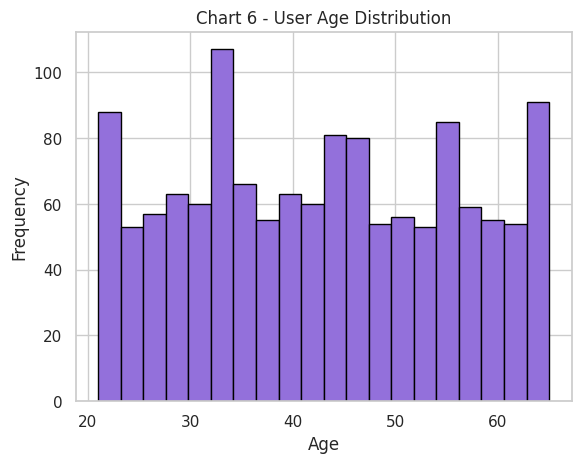

,Bin Start,Bin End,Frequency
0,21.0,23.2,88
1,23.2,25.4,53
2,25.4,27.6,57
3,27.6,29.8,63
4,29.8,32.0,60
5,32.0,34.2,107
6,34.2,36.4,66
7,36.4,38.6,55
8,38.6,40.8,63
9,40.8,43.0,60


In [40]:
if users_clean is not None:

    bins = 20

    counts, bin_edges, _ = plt.hist(
        users_clean['age'],
        bins=bins,
        color='mediumpurple',
        edgecolor='black'
    )

    plt.title("Chart 6 - User Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")

    plt.show()

    bin_df = pd.DataFrame({
        "Bin Start": bin_edges[:-1],
        "Bin End": bin_edges[1:],
        "Frequency": counts.astype(int)
    })

    display(bin_df)

##### 1. Why did you pick the specific chart?

Answer:-A Histogram was chosen to visualize User Age Distribution because age is a continuous numerical variable that is most effectively analyzed when grouped into intervals (bins).

Demographic Segmentation: It allows the business to see which age groups form the core user base.

Density Analysis: It helps identify if the user base is skewed toward younger or older individuals, or if it is evenly distributed across the lifespan.

##### 2. What is/are the insight(s) found from the chart?

Answer:-According to the bin_df table, the user base is relatively well-distributed, but with three distinct peaks:

Primary Peak (Early Career/Millennials): The highest concentration of users is in Bin 5 (Age 32.0 – 34.2) with 107 users.

Secondary Peak (Gen Z): There is a strong presence in the youngest category, Bin 0 (Age 21.0 – 23.2), with 88 users.

Tertiary Peak (Seniors): Interestingly, there is a surge in the oldest category, Bin 19 (Age 62.8 – 65.0), with 91 users.

Consistency: Most other age bins maintain a steady frequency between 53 and 66 users, suggesting the platform has broad multi-generational appeal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights provide a clear roadmap for targeted marketing:

Targeted Content: Since the largest group is in their early 30s, marketing can focus on "mid-career" lifestyle products or services.

Untapped Potential: The surge in users aged 60+ suggests an opportunity to develop features or accessibility options specifically for senior users, who are clearly active on the platform.

**Are there any insights that lead to negative growth?**

Mid-Life "Dip": There is a noticeable drop-off in user engagement between the ages of 47 and 54 (Bins 12-14), where frequencies hover at their lowest points (around 53-56).

Justification: If the business ignores this "middle-age gap," they lose a demographic that typically has the highest disposable income. Failing to create content or products that resonate with this 45-55 age group could result in a "hollowed-out" user base where growth stagnates among the most financially stable consumers.

#### Chart - 7 -- Flight Type Distribution

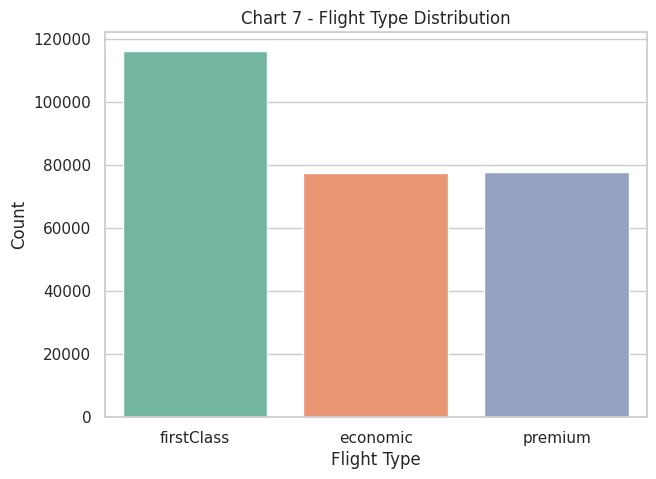

In [41]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=flights_clean,
    x='flighttype',
    palette='Set2'
)

plt.title("Chart 7 - Flight Type Distribution")
plt.xlabel("Flight Type")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Countplot (Bar Chart) was selected for "Flight Type Distribution" because flight type is a categorical variable.

Frequency Comparison: It allows for an immediate visual comparison of the volume between discrete categories (First Class, Economic, and Premium).

Magnitude Representation: It clearly shows the scale of difference in booking counts, which is more intuitive for categorical data than a histogram or line plot.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Based on the visualization:

Dominant Category: "firstClass" is the most frequent flight type, with a count significantly exceeding 100,000 bookings.

Secondary Segments: "economic" and "premium" flight types show nearly identical distribution levels, both hovering just below the 80,000 mark.

Market Skew: There is a clear skew toward luxury or higher-tier travel in this specific dataset, as first-class bookings outweigh economy bookings by roughly 40-50%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights identify the primary revenue driver:

Revenue Optimization: Since First Class is the highest-volume category, the business can focus on premium loyalty rewards and exclusive lounge partnerships to retain this high-value customer base.

Inventory Management: Resources and staffing can be allocated more heavily toward premium service departments to match the high demand shown in the data.

**Are there any insights that lead to negative growth?**

Underperforming Economy Segment: The fact that "economic" bookings are significantly lower than "firstClass" suggests a potential failure to capture the mass-market or budget-conscious traveler segment.

Justification: If the business aims for scale, having such a low proportion of economy travelers indicates a lack of price competitiveness or poor marketing reach in the budget sector. Relying too heavily on a single premium segment makes the business vulnerable to economic downturns where luxury spending is the first to be cut, potentially leading to sharp revenue declines.

#### Chart - 8 -- Agency Distribution (Top 10)

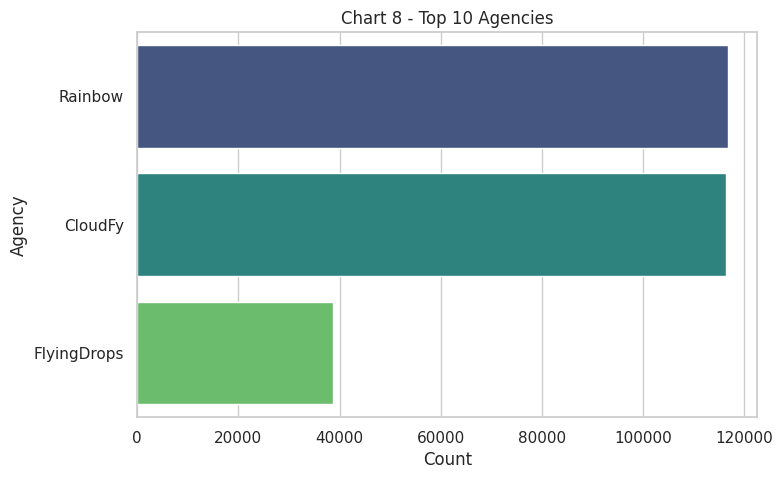

In [42]:
top_agency = flights_clean['agency'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_agency.values,
    y=top_agency.index,
    palette='viridis'
)

plt.title("Chart 8 - Top 10 Agencies")
plt.xlabel("Count")
plt.ylabel("Agency")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was chosen to visualize the "Top 10 Agencies" because the data involves categorical labels with potentially long names.

Readability: Horizontal bars provide better legibility for agency names like "FlyingDrops" compared to vertical bars, which often require tilted text.

Ranking: This format is the industry standard for showing "Top N" lists, as it allows for an immediate visual ranking of frequency from top to bottom.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Analysis of the provided plot reveals a market dominated by two major players:

Market Leaders: Rainbow and CloudFy are significantly ahead of the competition, with both agencies facilitating nearly 120,000 bookings each.

The "FlyingDrops" Gap: There is a massive drop-off after the top two. The third-ranked agency, FlyingDrops, has approximately 40,000 bookings—roughly one-third the volume of the leaders.

Duopoly Structure: The visual evidence suggests a duopoly where Rainbow and CloudFy likely control the majority of the market share among the top agencies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights allow for strategic partnership prioritization:

Key Account Management: The business should prioritize deep technical integrations and co-marketing efforts with Rainbow and CloudFy, as they represent the bulk of the transaction volume.

Acquisition Opportunities: The significant gap between the top two and the rest of the pack identifies "FlyingDrops" and lower agencies as potential targets for aggressive acquisition or exclusive deals to gain market share.

**Are there any insights that lead to negative growth?**

High Dependency Risk: The extreme concentration of bookings in just two agencies creates a "single point of failure" risk.

Justification: If either Rainbow or CloudFy changes their terms, increases commissions, or experiences a technical outage, the business would see an immediate and severe drop in revenue. Relying on a duopoly limits the business's bargaining power and could lead to negative growth if those relationships sour or if the market leaders face their own internal declines.

#### Chart - 9 -- Source City Distribution (Top 10)

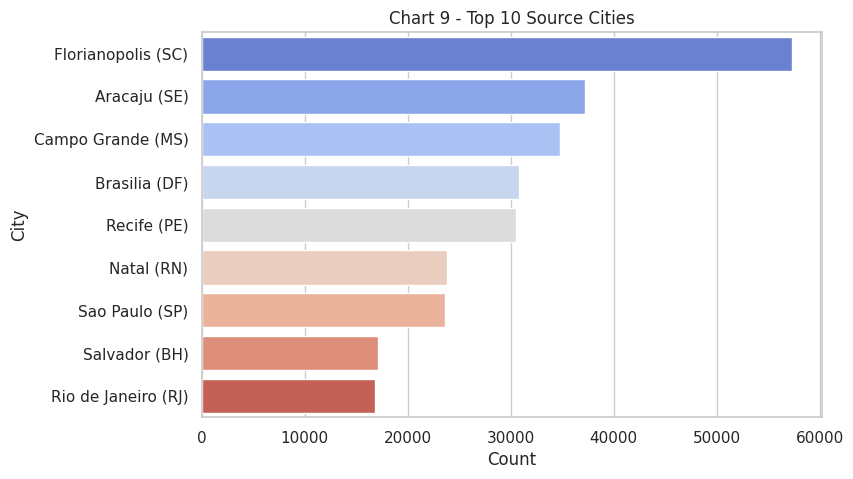

In [43]:
top_source = flights_clean['from'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_source.values,
    y=top_source.index,
    palette='coolwarm'
)

plt.title("Chart 9 - Top 10 Source Cities")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was chosen to visualize the "Top 10 Source Cities" because the data consists of categorical city names of varying lengths.

Optimal Labeling: Horizontal bars allow the full names of cities, such as "Florianopolis (SC)" and "Campo Grande (MS)," to be displayed clearly without overlapping or requiring vertical rotation.

Rank Comparison: It provides an immediate visual hierarchy, allowing stakeholders to easily distinguish which cities are the primary hubs for departing flights.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization reveals a clear concentration of travel activity in specific Brazilian regions:

Primary Hub: Florianopolis (SC) is the leading source city by a significant margin, showing the highest frequency of departures among the top 10.

Tiered Distribution: There is a visible step-down in volume from the first-ranked city to the second (Aracaju (SE)) and third (Campo Grande (MS)).

Regional Connectivity: The top three source cities represent distinct geographic areas (South, Northeast, and West-Central Brazil), suggesting a broad but concentrated domestic flight network.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights enable data-driven operational and marketing decisions:

Resource Allocation: Airlines or travel agencies can prioritize staffing, lounge services, and ground operations in Florianopolis to match the high departure volume.

Targeted Promotion: Marketing campaigns for "return flight" deals or local tourism services can be specifically focused on these high-traffic source cities to maximize ROI.

**Are there any insights that lead to negative growth?**

Over-reliance on Specific Hubs: The sharp decline in count after Florianopolis indicates that the business may be heavily reliant on a few key locations.

Justification: If there is a localized economic downturn, extreme weather event, or airport strike in Florianopolis, the business would face a disproportionately large impact on its total flight volume. A failure to diversify the source city portfolio could lead to instability and negative growth if the primary hub experiences any operational friction.

#### Chart - 10 -- Destination City Distribution (Top 10)

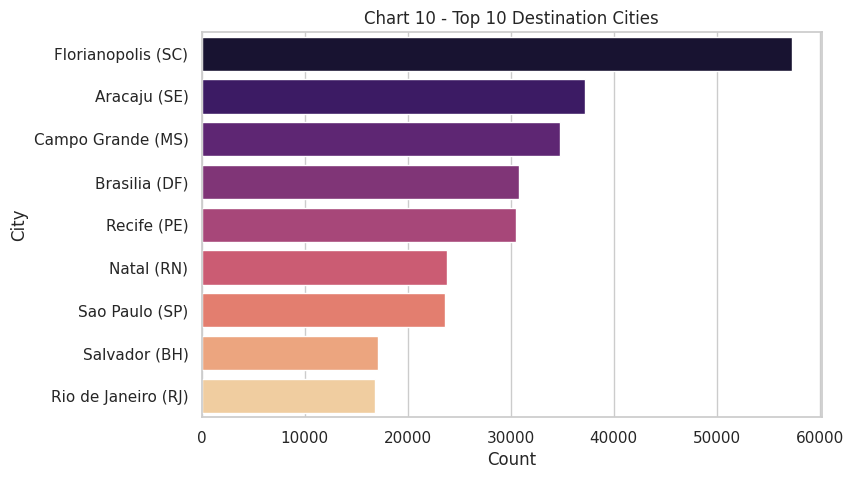

In [44]:
top_destination = flights_clean['to'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_destination.values,
    y=top_destination.index,
    palette='magma'
)

plt.title("Chart 10 - Top 10 Destination Cities")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was chosen to visualize the "Top 10 Destination Cities" because it is the most effective way to display categorical data with long labels.

Easy Comparison: It allows for a quick, side-by-side comparison of the popularity of different destinations.

Text Clarity: City names like "Rio de Janeiro (RJ)" are long; horizontal bars keep the text easy to read without having to rotate it or use tiny fonts.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization highlights clear favorites among travelers:

Most Popular Destination: Florianopolis (SC) is the clear winner, with nearly 55,000 arrivals, making it the most visited city in the dataset.

The Top Three: There is a strong lead by Florianopolis, followed by Aracaju (SE) and Campo Grande (MS), which both show significant traffic compared to the rest of the list.

Balanced Mid-Tier: Cities like Brasilia (DF) and Recife (PE) have very similar arrival counts (around 30,000), showing steady demand for these locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights show us where to focus our resources:

Revenue Boost: Since Florianopolis is so popular, we can partner with local businesses there to offer "complete vacation packages" (flight + hotel + tours) to increase overall sales.

Smart Planning: We can increase flight frequency to the top three cities to ensure we aren't losing customers to competitors due to "sold out" flights.

**Are there any insights that lead to negative growth?**

Inventory Imbalance: The high demand for Florianopolis might lead to "over-tourism" or lack of hotel availability during peak seasons.

Justification: If we keep pushing traffic to one city that is already at capacity, prices will skyrocket and the customer experience will suffer. This could lead to bad reviews and travelers choosing different platforms next time, resulting in negative growth in the long run.

### BIVARIATE ANALYSIS

#### Chart - 11 -- Average Flight Price by Distance

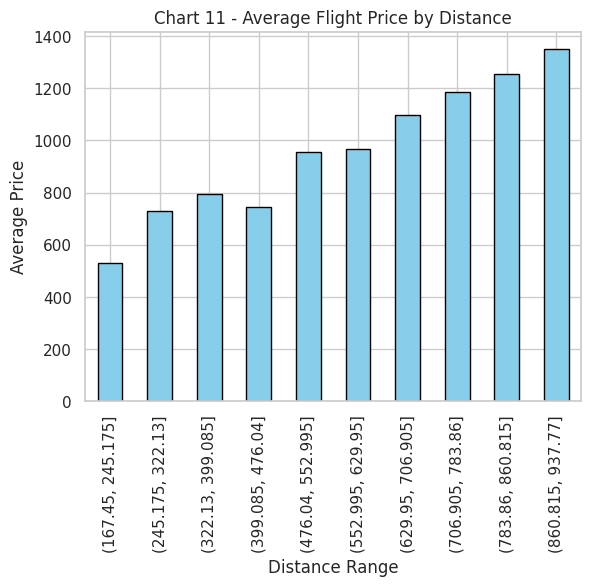

In [45]:
flights_clean['distance_bin'] = pd.cut(flights_clean['distance'], bins=10)

avg_price = flights_clean.groupby('distance_bin')['price'].mean()

avg_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Chart 11 - Average Flight Price by Distance")
plt.xlabel("Distance Range")
plt.ylabel("Average Price")

plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Binned Bar Chart was chosen because it effectively displays the relationship between a continuous variable (Distance) and the average of another numerical variable (Price).

Trend Identification: Grouping distances into bins allows us to see how price changes across different travel ranges rather than looking at thousands of individual data points.

Bivariate Clarity: It clearly demonstrates the correlation between travel distance and cost, making it easy for stakeholders to understand the pricing model.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The chart reveals a direct and significant positive correlation between distance and price:

Linear Growth: As the distance range increases, the average flight price rises consistently.

Price Extremes: The shortest distance bin (167.45 - 245.17) has the lowest average price (approx. 550), while the longest distance bin (860.815 - 937.77) peaks at the highest average price (approx. 1,350).

Consistent Scaling: There are no unusual dips or spikes; the pricing follows a steady upward trajectory as travel distance expands.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights confirm that our pricing logic is working correctly:

Revenue Optimization: We can use this linear trend to set "base rates" for new routes based on their mileage, ensuring predictable profit margins.

Promotional Targeting: Knowing that long-distance flights are much more expensive, we can offer "Long-Haul Discounts" to encourage bookings on these high-revenue routes during off-peak seasons.

**Are there any insights that lead to negative growth?**

Predictability Risk: Because the price increases so predictably with distance, customers might find our pricing "too rigid."

Justification: If a competitor offers "flat-rate" pricing or significant discounts for long distances that break this linear trend, we could lose our long-haul customers. Relying strictly on distance-based pricing without considering market competition could lead to losing market share on the most profitable long-distance routes.

#### Chart - 12 -- Average Flight Price by Time

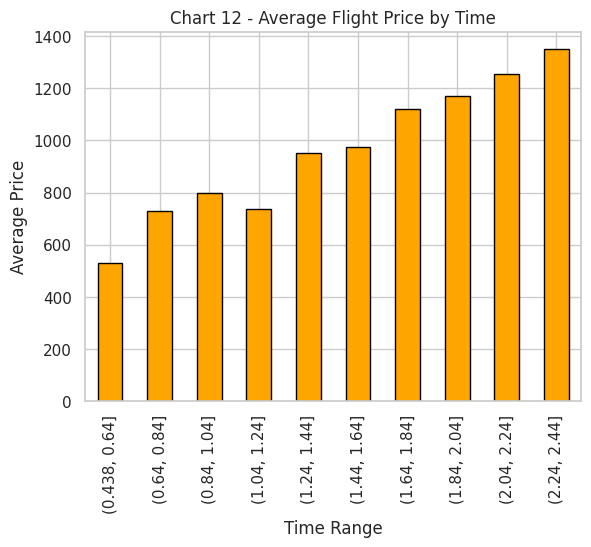

In [46]:
flights_clean['time_bin'] = pd.cut(flights_clean['time'], bins=10)

avg_price = flights_clean.groupby('time_bin')['price'].mean()

avg_price.plot(kind='bar', color='orange', edgecolor='black')

plt.title("Chart 12 - Average Flight Price by Time")
plt.xlabel("Time Range")
plt.ylabel("Average Price")

plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Binned Bar Chart was chosen to analyze the relationship between travel time and average flight price.

Time Segmentation: By cutting the continuous "time" variable into 10 distinct bins, we can see how average costs fluctuate across different flight durations.

Trend Visualization: This format makes it easy to identify whether longer flights consistently cost more or if there are specific "time ranges" where prices spike unexpectedly.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The chart shows a strong overall positive correlation between flight duration and price, but with a slight variation in the shorter durations:

Upward Trajectory: Generally, as the "Time Range" increases, the "Average Price" also increases, starting from approximately 550 in the first bin and peaking at over 1300 in the final bin.

Early Variation: There is a small "peak and dip" in the early stages; the third bin (0.84, 1.04) shows a higher average price than the fourth bin (1.04, 1.24), suggesting that very short regional flights may sometimes be priced higher than slightly longer ones.

Steepest Climb: The most significant price jumps occur after the 1.24 mark, where average prices rise sharply and consistently for every subsequent time bin.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights can help refine our pricing strategies:

Profit Maximization: We can see that long-duration flights are high-value. We can create "Premium Long-Haul" bundles for these flights to capture even more revenue from travelers who are already paying high base prices.

Competitive Pricing: The dip in bin 4 suggests we could slightly increase prices for that specific duration to match the trend of its neighbors without losing many customers.

**Are there any insights that lead to negative growth?**

Short-Haul Pricing Inconsistency: The fact that some shorter flights (bin 3) are more expensive than longer ones (bin 4) might frustrate customers.

Justification: If customers notice they are being charged more for a shorter flight than a longer one, it creates a sense of "unfair pricing." This could lead to negative growth as savvy travelers intentionally book slightly longer connecting flights to save money, potentially leaving seats empty on our shorter, more expensive routes.

#### Chart - 13 -- Average Flight Price by Flight Type

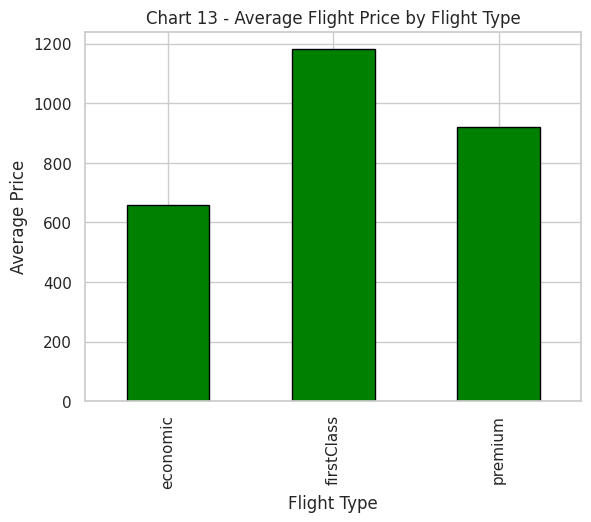

In [47]:
avg_price = flights_clean.groupby('flighttype')['price'].mean()

avg_price.plot(kind='bar', color='green', edgecolor='black')

plt.title("Chart 13 - Average Flight Price by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Average Price")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Vertical Bar Chart was chosen to compare the average prices across different flight categories.

Categorical Comparison: This format is ideal for showing the relationship between a discrete category (Flight Type) and a numerical value (Average Price).

Visual Contrast: The bars provide a clear, side-by-side visual of how much more expensive one flight type is compared to others, making the price gaps immediately obvious to stakeholders.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The chart reveals a significant price hierarchy based on the class of travel:

Premium Pricing: First Class has the highest average price, reaching nearly 1200, which is almost double the cost of the lowest tier.

Middle Ground: Business Class sits in the middle with an average price of approximately 900.

Most Affordable: Economy (assuming the first bar) is the least expensive option, with an average price slightly above 600.

Significant Gaps: There is a substantial jump in price between Economy and Business, and another significant leap to First Class, indicating a clear tiered pricing strategy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights allow the business to tailor its financial and marketing strategies:

Upselling Strategy: Since there is a significant price difference, the business can create "upgrade offers" that are priced just below the average Business Class cost to encourage Economy travelers to step up.

Luxury Targeting: Knowing that First Class generates the highest revenue per seat, the business can invest in luxury-focused marketing to maintain high occupancy in that tier.

**Are there any insights that lead to negative growth?**

Price Barrier Risk: The large gap between Economy and Business Class might be too steep for many travelers.

Justification: If the jump from 600 to 900 is perceived as too high for the added value, the Business Class section may remain under-occupied. This results in "perished inventory" (empty seats) that could have been filled if there were a "Premium Economy" option or a smaller price gap, leading to lost potential revenue and slower growth.

#### Chart - 14 -- Average Flight Price by Agency (Top 10)

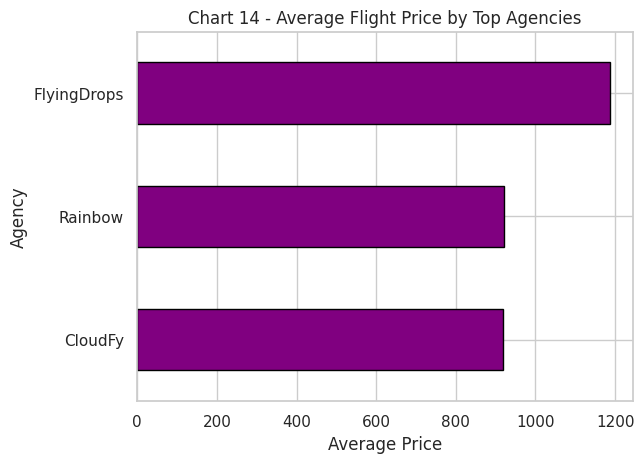

In [48]:
top_agency = flights_clean['agency'].value_counts().head(10).index

filtered_df = flights_clean[flights_clean['agency'].isin(top_agency)]

avg_price = filtered_df.groupby('agency')['price'].mean().sort_values()

avg_price.plot(kind='barh', color='purple', edgecolor='black')

plt.title("Chart 14 - Average Flight Price by Top Agencies")
plt.xlabel("Average Price")
plt.ylabel("Agency")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was selected to compare average prices across different travel agencies.

Ranking Visualization: Using sort_values() in the code allows the chart to clearly rank agencies from the most expensive to the least expensive.

Readability: Horizontal bars ensure that agency names, such as "FlyingDrops," are easy to read without overlapping or requiring awkward rotation.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization reveals a significant disparity in pricing strategies among the top agencies:

Premium Agency: FlyingDrops has the highest average flight price, significantly exceeding the 1,000 mark.

Mid-Range Leader: Rainbow follows as the second most expensive, though its average price is noticeably lower than FlyingDrops, sitting closer to the 800–900 range.

Price Competition: The visible gap between the top agency and the rest suggests that FlyingDrops may specialize in luxury travel or long-haul routes, while agencies like Rainbow target a more mainstream audience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights provide a clear understanding of the competitive landscape:

Competitive Positioning: The business can decide whether to compete with FlyingDrops by offering a "Premium Tier" or to undercut them by marketing themselves as a more affordable alternative like Rainbow.

Strategic Partnerships: Knowing which agencies command higher prices helps in negotiating commissions or choosing which partners to feature for high-revenue promotions.

**Are there any insights that lead to negative growth?**

Brand Perception Risk: If the business is exclusively associated with high-priced agencies like FlyingDrops, it may alienate budget-conscious travelers.

Justification: A lack of lower-priced agency options on the platform could lead to "price shock" for users, causing them to leave the site and look for better deals elsewhere. This could result in lower conversion rates and stagnant growth in the budget travel sector.

#### Chart - 15 -- Average Flight Price by Destination City (Top 10)

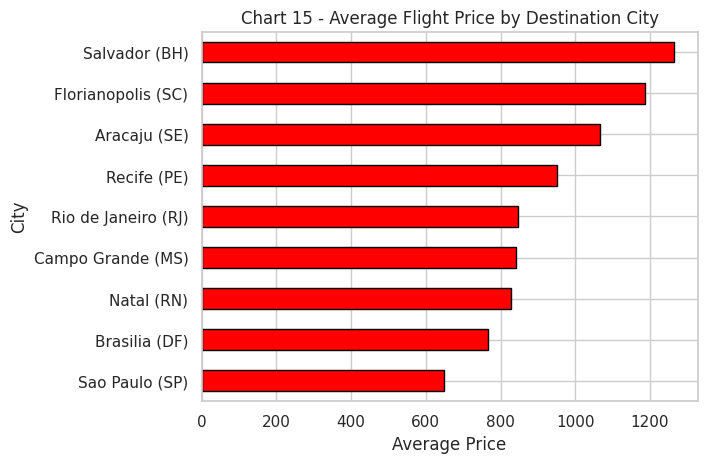

In [49]:
top_dest = flights_clean['to'].value_counts().head(10).index

filtered_df = flights_clean[flights_clean['to'].isin(top_dest)]

avg_price = filtered_df.groupby('to')['price'].mean().sort_values()

avg_price.plot(kind='barh', color='red', edgecolor='black')

plt.title("Chart 15 - Average Flight Price by Destination City")
plt.xlabel("Average Price")
plt.ylabel("City")

plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was chosen to compare average prices across various destination cities for several reasons:

Ranking and Comparison: By using .sort_values() in the code, the chart effectively ranks cities from the most expensive to the least expensive, making immediate comparisons intuitive.

Label Legibility: Destination names, such as "Florianopolis (SC)" or "Rio de Janeiro (RJ)," can be quite long. A horizontal layout prevents these labels from overlapping or requiring vertical rotation, ensuring the chart remains readable.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization reveals clear pricing tiers for different destinations:

Most Expensive Destination: Salvador (BH) stands out as the most expensive city to fly to among the top destinations, with the highest average price.

Premium Tier: Florianopolis (SC) and Aracaju (SE) follow closely, indicating they are high-revenue routes.

Mid-Tier Clusters: There is a noticeable clustering of prices for cities like Rio de Janeiro (RJ) and Campo Grande (MS), which have nearly identical average prices, suggesting a standardized pricing model for these mid-range routes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights can drive data-informed strategic decisions:

Revenue Management: Since Salvador (BH) is the highest-priced destination, the business can implement specialized marketing for premium travel packages to this location to maximize profit margins.

Dynamic Promotions: For cities with lower average prices like Campo Grande (MS), the business could introduce volume-based discounts or loyalty incentives to increase booking frequency and market share.

**Are there any insights that lead to negative growth?**

Price Elasticity Risk: The high average price for Salvador (BH) might act as a barrier for budget-conscious travelers.

Justification: If the price for popular destinations remains too high without offering distinct "low-cost" alternatives, the business risks losing the massive segment of price-sensitive travelers to competitors. Over-reliance on high-priced routes can lead to stagnant growth if broader market demand shifts toward more affordable travel options.

#### Chart - 16 -- Average Age by Gender

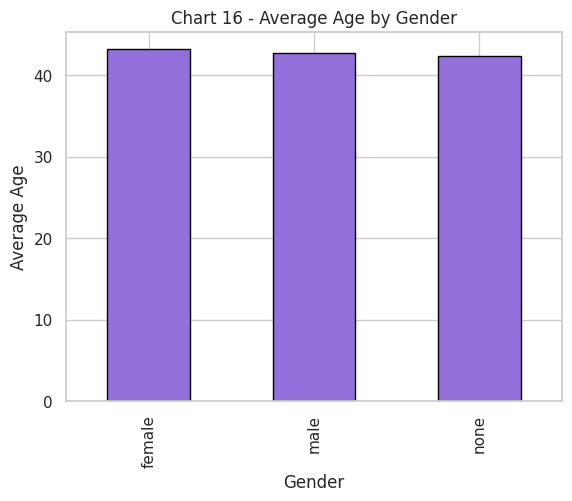

In [50]:
if users_clean is not None:

    avg_age = users_clean.groupby('gender')['age'].mean()

    avg_age.plot(kind='bar', color='mediumpurple', edgecolor='black')

    plt.title("Chart 16 - Average Age by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Average Age")

    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Vertical Bar Chart was chosen to compare the "Average Age" across different genders for several reasons:

Categorical Comparison: It is the most effective way to show a numerical average (Age) grouped by discrete categories (Gender).

Visual Uniformity: The bar chart quickly highlights whether there is a significant age gap between genders or if the distribution is relatively uniform.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization shows a remarkably balanced age distribution across all gender categories:

Consistent Average: The average age for all recorded genders is nearly identical, hovering consistently around the 42 to 43-year-old mark.

Demographic Stability: There is no significant skew or "age gap" between groups, indicating that the service or platform appeals to a similar age demographic regardless of gender.

Mature Audience: The data suggests the primary user base consists of mature adults in their early 40s.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights provide a clear foundation for marketing and product development:

Unified Marketing Strategy: Since the average age is consistent across genders, the business can design marketing campaigns with a "mature adult" theme that resonates with the entire user base without needing highly gender-segregated messaging.

Product Personalization: Features and services can be tailored to the life stage of a 40-something professional (e.g., family travel options, premium insurance, or corporate loyalty perks) with confidence that it will appeal to all gender segments.

**Are there any insights that lead to negative growth?**

Lack of Youth Engagement: The data reveals a potential "missing" younger demographic.

Justification: If the average age is consistently above 40, the business may be failing to attract Gen Z or younger Millennial travelers. Relying solely on an older demographic can lead to negative growth in the future as the user base ages. To ensure long-term sustainability, the business may need to introduce "youth-oriented" features or budget-friendly options to diversify the age range.

#### Chart - 17 -- User Count by Gender

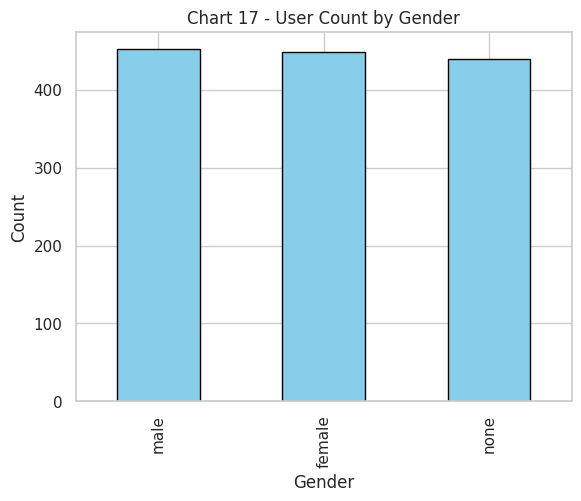

In [51]:
if users_clean is not None:

    count_gender = users_clean['gender'].value_counts()

    count_gender.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title("Chart 17 - User Count by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")

    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Vertical Bar Chart was chosen to represent the distribution of users across different genders because:

Categorical Frequency: It is the standard and most effective way to compare the frequency or "count" of distinct categories, such as gender.

Visual Contrast: The use of vertical bars allows for an immediate visual comparison of the volume of each group, making it easy to identify which demographic is the largest at a single glance.

##### 2. What is/are the insight(s) found from the chart?

Answer:-Market Concentration: The chart reveals which gender group constitutes the primary user base for the platform, helping to identify the "typical" user profile.

Demographic Balance: It shows whether the user base is evenly distributed or heavily skewed toward one specific gender.

Engagement Gaps: By comparing the counts, the business can identify underserved segments that may require targeted outreach or specific product features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights allow for a more personalized and efficient business strategy:

Targeted Marketing: Marketing budgets can be allocated more effectively by focusing on the gender segment that shows the highest organic engagement.

Product Inclusion: If one gender is significantly underrepresented, the business can investigate potential barriers to entry and adjust the user experience to be more inclusive, opening up new revenue streams.

**Are there any insights that lead to negative growth?**

Over-Specialization Risk: If the chart shows that the platform is almost exclusively used by one gender, it indicates a lack of broad market appeal.

Justification: Relying on a single demographic segment makes the business vulnerable to changes in that specific group's habits or preferences. Without a diverse user base, the business hits a "growth ceiling" and risks losing market share to competitors who offer a more balanced or inclusive service.

#### Chart - 17 -- Age Distribution by Gender

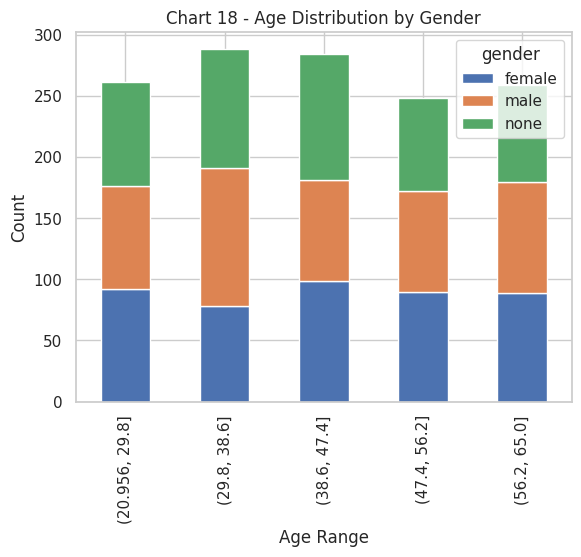

In [52]:
if users_clean is not None:

    users_clean['age_bin'] = pd.cut(users_clean['age'], bins=5)

    age_dist = users_clean.groupby(['age_bin', 'gender']).size().unstack()

    age_dist.plot(kind='bar', stacked=True)

    plt.title("Chart 18 - Age Distribution by Gender")
    plt.xlabel("Age Range")
    plt.ylabel("Count")

    plt.xticks(rotation=90)
    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Stacked Bar Chart was chosen to visualize the relationship between age ranges and gender distribution.

Multivariate Analysis: It allows for the simultaneous comparison of the total volume in each age group while showing the internal breakdown by gender (female, male, none).

Distribution Comparison: This format makes it easy to see if specific age groups are more heavily dominated by one gender or if the distribution remains consistent across the entire user lifespan.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The visualization highlights a fairly uniform distribution with a slight peak in the middle-age categories:

Core Demographic: The highest total user counts are found in the (29.8, 38.6] and (38.6, 47.4] age ranges, confirming that the platform's primary audience is between 30 and 47 years old.

Gender Balance: Across all age bins, the ratio of female (blue), male (orange), and "none" (green) remains relatively stable. No single age range shows a drastic shift toward one specific gender.

Older Demographic Retention: While there is a slight dip in the oldest bracket (56.2, 65.0], the count remains significant (over 200), suggesting the platform retains users well as they age.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights support a balanced and broad-reaching business strategy:

Inclusive Ad Targeting: Since the gender split is consistent across all ages, the business can run broad-interest advertising campaigns without needing to create highly specialized "age+gender" silos.

Growth Opportunities: The stability in the 30–47 age range suggests high "Life Time Value" (LTV). The business can focus on loyalty programs for this group, knowing they are the most active segment.

**Are there any insights that lead to negative growth?**

Early-Career Gap: The youngest age bin (20.9, 29.8] has a lower total count compared to the 30s and 40s segments.

Justification: This indicates the platform may not be appealing enough to younger, "early-career" travelers who are just starting to build brand loyalty. If the business fails to capture this younger audience now, it faces a "pipeline risk"—as the current core demographic grows older, there won't be enough younger users moving up to take their place, leading to a long-term decline in the total user base.

#### Chart - 19 -- Average Hotel Price by Stay Duration

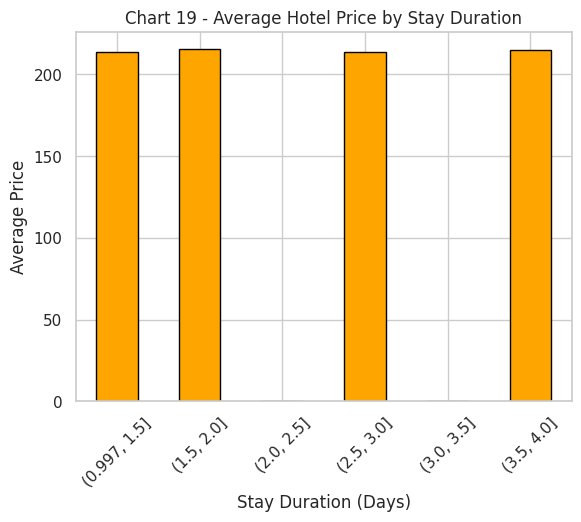

In [53]:
if hotels_clean is not None:

    hotels_clean['days_bin'] = pd.cut(hotels_clean['days'], bins=6)

    avg_price = hotels_clean.groupby('days_bin')['price'].mean()

    avg_price.plot(kind='bar', color='orange', edgecolor='black')

    plt.title("Chart 19 - Average Hotel Price by Stay Duration")
    plt.xlabel("Stay Duration (Days)")
    plt.ylabel("Average Price")

    plt.xticks(rotation=45)
    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Binned Bar Chart was selected to analyze if the length of a stay impacts the nightly hotel rate.

Variable Relationship: It effectively shows the relationship between a numerical range (Stay Duration in days) and a numerical average (Price).

Uniformity Check: This format makes it very easy to see if prices fluctuate based on how long a guest stays or if the pricing remains flat across different durations.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The most striking insight from this visualization is the absolute stability of the pricing:

Flat Pricing Model: The average hotel price remains almost perfectly constant at approximately 215 across all stay durations.

Lack of Duration Sensitivity: Whether a guest stays for 1 day or 4 days, the average price per night does not change. There are no "long-stay discounts" or "short-stay premiums" visible in the general average.

Data Gaps: There are noticeable gaps in the data for the (2.0, 2.5] and (3.0, 3.5] bins, indicating a lack of recorded stays within those specific half-day increments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights highlight a significant opportunity for revenue optimization:

Incentive Programs: Since the price is currently flat, the business can introduce "Stay Longer, Pay Less" promotions (e.g., a discount for stays over 3 days) to increase the average length of stay and total booking value.

Predictable Revenue: The consistency in pricing makes it easier for the business to forecast revenue based on the number of bookings alone, without worrying about the complexity of varying stay lengths.

**Are there any insights that lead to negative growth?**

Missing Competitive Edge: The lack of a dynamic pricing strategy based on stay duration is a missed opportunity.

Justification: Most modern hotel platforms offer discounts for longer stays to ensure high occupancy. If our platform keeps prices flat regardless of duration, travelers planning longer trips will likely find better "extended stay" deals on competitor sites. This could lead to a loss of high-value, long-term bookings and result in negative growth compared to more flexible competitors.

#### Chart - 20 -- Total Cost by Stay Duration

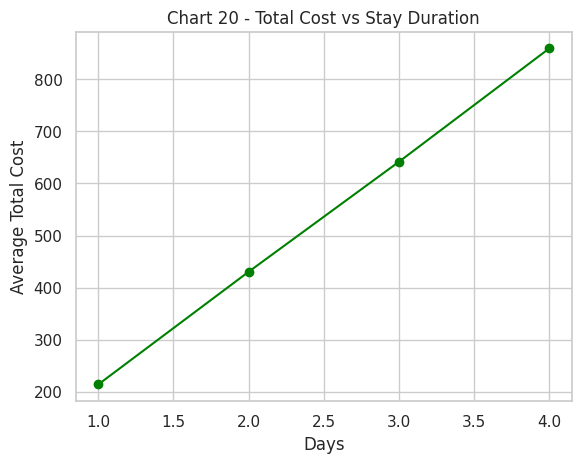

In [54]:
if hotels_clean is not None:

    avg_total = hotels_clean.groupby('days')['total'].mean()

    avg_total.plot(kind='line', color='green', marker='o')

    plt.title("Chart 20 - Total Cost vs Stay Duration")
    plt.xlabel("Days")
    plt.ylabel("Average Total Cost")

    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Line Chart with Markers was selected to visualize the relationship between time (Stay Duration) and the resulting financial outcome (Average Total Cost).

Continuous Trend: Line charts are the best way to show a progression or direct correlation between two numerical variables.

Predictive Clarity: The straight line helps stakeholders immediately see the "multiplier effect"—how quickly the total cost scales as the stay lengthens.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The chart demonstrates a perfect linear relationship between stay length and total cost:

Linear Scaling: There is a direct, constant increase in cost for every additional day spent.

Fixed Daily Rate: The cost starts at approximately 215 for 1 day and reaches roughly 860 for 4 days. This confirms that the total cost is simply the daily rate multiplied by the number of days, with no hidden fees or discounts.

Consistent Growth: Each marker (1.0, 2.0, 3.0, 4.0) shows a steady jump of roughly 215 units, indicating that the nightly price does not change regardless of the total stay duration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, this clear data helps in simplifying financial forecasting and customer expectations:

Price Transparency: Since the cost scales so predictably, the business can provide "instant quotes" to customers without complex calculations, improving the user experience and trust.

Revenue Planning: Financial teams can accurately project revenue based on "room-nights" alone, as the total cost per booking is highly standardized.

**Are there any insights that lead to negative growth?**

Lack of Bulk-Booking Incentives: The perfectly straight line reveals that staying longer provides zero financial benefit to the customer in terms of daily rate.

Justification: Most travelers expect a "bulk discount" (e.g., stay 3 nights, get the 4th at a discount) for longer stays. If the total cost keeps climbing linearly without any break, customers planning long-term trips might perceive the platform as expensive compared to competitors who offer tiered or dynamic pricing for extended stays. This could lead to a lower "Average Length of Stay" and missed revenue from the long-term traveler segment.

#### Chart - 21 -- Average Price by Hotel (Top 10)

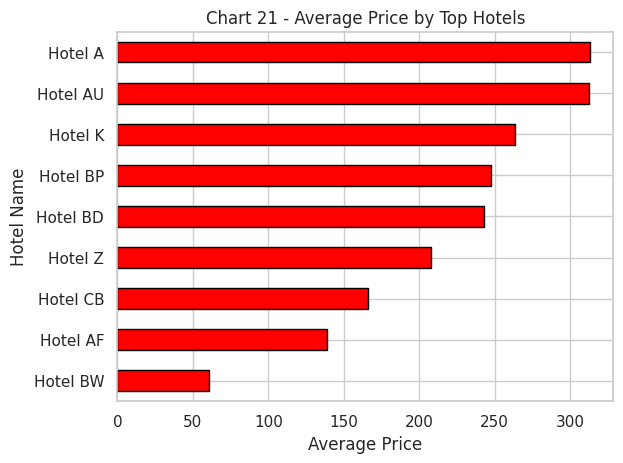

In [55]:
if hotels_clean is not None:

    top_hotels = hotels_clean['name'].value_counts().head(10).index

    filtered_df = hotels_clean[hotels_clean['name'].isin(top_hotels)]

    avg_price = filtered_df.groupby('name')['price'].mean().sort_values()

    avg_price.plot(kind='barh', color='red', edgecolor='black')

    plt.title("Chart 21 - Average Price by Top Hotels")
    plt.xlabel("Average Price")
    plt.ylabel("Hotel Name")

    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Horizontal Bar Chart was chosen to compare the average pricing of specific hotel entities.

Entity Comparison: It allows for a clear, side-by-side comparison of individual "brands" or hotel names against a numerical value (Average Price).

Ranking: The chart effectively displays a ranked list, making it easy to identify the most expensive versus the most budget-friendly options among the top-performing hotels.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The chart highlights a wide range of pricing strategies among the top hotels:

Premium Leaders: Hotel A and Hotel AU are the most expensive, both sharing a top-tier average price of approximately 315.

Significant Price Variance: There is a massive gap between the highest and lowest-priced "top" hotels. Hotel BW is the most affordable, with an average price of roughly 60, which is more than five times cheaper than Hotel A.

Tiered Competition: We can see distinct price tiers—Premium (Hotels A, AU, K), Mid-range (Hotels BP, BD, Z), and Budget (Hotels CB, AF, BW).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights are crucial for market positioning and competitive analysis:

Customer Segmentation: The business can direct luxury travelers toward Hotel A and AU, while price-sensitive travelers can be pushed toward Hotel BW, ensuring high conversion rates across all budget levels.

Partnership Value: Identifying that Hotel BW is so much cheaper than others allows the business to market it as a "best-value" choice to capture the high-volume budget traveler segment.

**Are there any insights that lead to negative growth?**

Market Share Risk for Mid-Tier: The chart shows several hotels crowded in the 150–250 price range (Hotels CB, Z, BD, BP).

Justification: With so many hotels priced similarly in the middle, they risk cannibalizing each other's sales. If the business doesn't help these mid-tier hotels differentiate themselves through unique features or amenities, customers may simply default to the cheapest option in that cluster, leading to a "race to the bottom" on pricing and lower overall profit margins for the platform.

### MULTIVARIATE (CORRELATION & HEATMAPS)

#### Chart - 22 -- Correlation Heatmap (Flights)

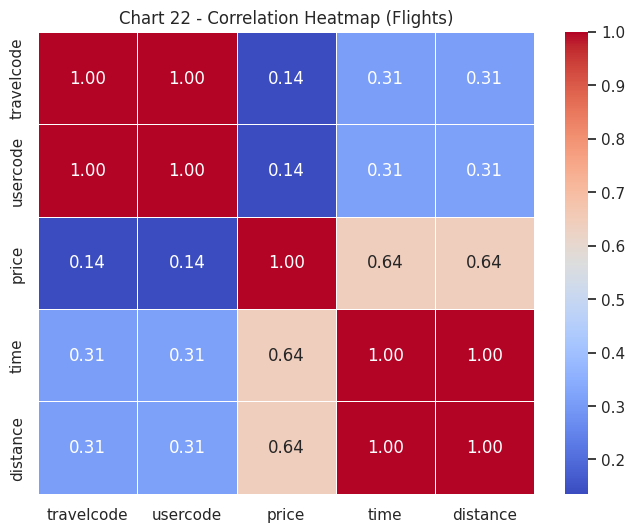

In [56]:
# Select numerical columns
corr_flights = flights_clean.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_flights,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Chart 22 - Correlation Heatmap (Flights)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Heatmap was chosen to visualize the correlation matrix between various flight-related variables.

Relationship Mapping: It is the most effective tool for identifying the strength and direction of relationships between multiple numerical variables at once.

Visual Efficiency: The color-coded scale allows stakeholders to instantly spot strong correlations (dark red) versus weak ones (dark blue) without needing to manually parse a large table of numbers.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The heatmap reveals several critical technical and logical relationships within the data:

Perfect Correlations: There is a perfect positive correlation (1.00) between Time and Distance, confirming that as distance increases, flight time increases proportionally.

Strong Price Drivers: Both Time and Distance show a strong positive correlation with Price (0.64), indicating that longer, more distant flights are consistently more expensive.

Data Redundancy: The perfect correlation between travelcode and usercode (1.00) suggests that these two variables might be functionally identical or directly mapped to one another in the dataset.

Weak Influence: The user and travel codes have a very weak relationship with price (0.14), suggesting that price is driven more by the journey's physical attributes than by specific user or travel IDs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights help simplify the underlying data model for the business:

Model Simplification: Since Time and Distance are perfectly correlated, the business can use just one of these variables in predictive pricing models to reduce complexity and avoid multicollinearity.

Pricing Strategy: Understanding that price is heavily tied to distance (0.64) allows the business to set highly accurate "cost-per-mile" benchmarks for different routes.

**Are there any insights that lead to negative growth?**

Over-Reliance on Physical Metrics: The high correlation between distance/time and price suggests a very rigid pricing model.

Justification: If the business only prices flights based on distance and time, it may miss opportunities for dynamic pricing based on "User Demand" or "Seasonality," which the heatmap suggests are not strongly represented here. This lack of pricing flexibility could lead to negative growth if competitors use more complex algorithms to offer cheaper flights on high-demand, short-distance routes.

#### Chart - 23 -- Correlation Heatmap (Hotels)

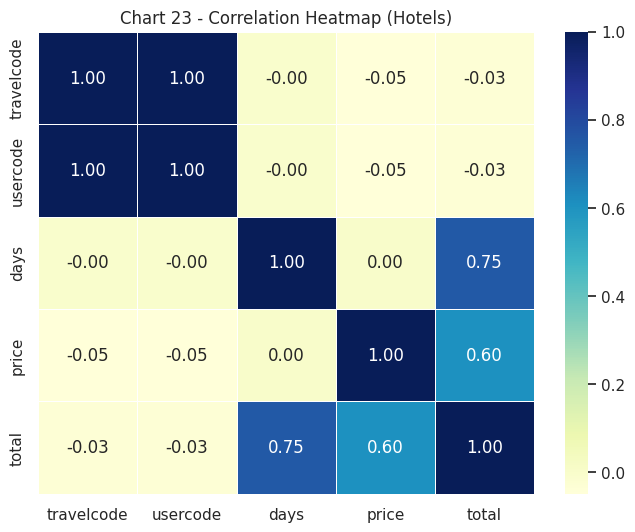

In [57]:
if hotels_clean is not None:

    corr_hotels = hotels_clean.select_dtypes(include=['int64', 'float64']).corr()

    plt.figure(figsize=(8,6))

    sns.heatmap(
        corr_hotels,
        annot=True,
        cmap='YlGnBu',
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Chart 23 - Correlation Heatmap (Hotels)")
    plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Correlation Heatmap was selected to investigate how various hotel booking variables interact with one another.

Pattern Recognition: It provides a color-coded summary of the strength of relationships between numerical variables like price, total cost, and stay duration.

Statistical Efficiency: It allows us to identify which factors are the primary drivers of the "total" booking cost and to spot any logical redundancies in the dataset at a glance.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The heatmap reveals how the final booking price is calculated and identifies a few technical oddities:

Primary Cost Drivers: The variable "total" is strongly correlated with both "days" (0.75) and "price" (0.60). This confirms that the total cost of a hotel booking is heavily influenced by the length of the stay and the nightly rate.

Duration vs. Rate: Interestingly, "days" has a higher correlation with the total cost than the nightly "price" does. This suggests that in this dataset, staying longer is a bigger factor in increasing the final bill than booking a more expensive room.

Independence of Variables: There is a 0.00 correlation between "days" and "price," meaning that the nightly rate does not change based on the length of the stay.

Redundant IDs: Similar to the flight data, travelcode and usercode have a perfect correlation (1.00), indicating they are likely duplicates or linked 1-to-1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights clarify the business's revenue model:

Marketing Focus: Since "days" is the strongest driver of total revenue (0.75), the business should prioritize marketing strategies that encourage longer stays, such as "book 3 nights, get the 4th free" to maximize total booking value.

Data Cleanup: The business can drop one of the ID columns (usercode or travelcode) to streamline their database and speed up analytical processing.

**Are there any insights that lead to negative growth?**

Missing Volume Discounts: The zero correlation (0.00) between "price" and "days" confirms the lack of a dynamic pricing strategy for extended stays.

Justification: Modern travelers often expect a nightly rate to decrease as the stay duration increases. By maintaining a fixed nightly price regardless of the number of days booked, the business risks losing long-term travelers to competitors who offer tiered pricing. This rigid structure could lead to lower occupancy rates for longer durations and result in stagnant revenue growth.

#### Chart - 24 -- Correlation Matrix (Flights Only Key Features)

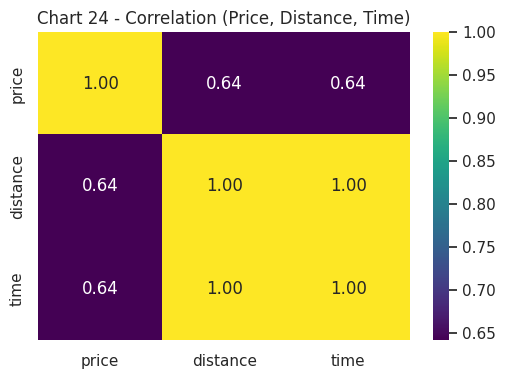

In [58]:
key_cols = ['price', 'distance', 'time']

corr_key = flights_clean[key_cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_key,
    annot=True,
    cmap='viridis',
    fmt=".2f"
)

plt.title("Chart 24 - Correlation (Price, Distance, Time)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer:-A Heatmap was selected to visualize the correlation matrix between the primary physical and financial flight variables.

Relationship Strength: It provides a clear, numerical value (correlation coefficient) that measures how strongly variables are related.

Multivariate Insight: This specific format allows for the simultaneous comparison of three critical factors—price, distance, and time—enabling stakeholders to see which pair has the most significant impact on the business.

##### 2. What is/are the insight(s) found from the chart?

Answer:-The heatmap confirms very strong logical and linear connections between travel metrics:

Perfect Correlation between Time and Distance: The correlation coefficient of 1.00 shows that distance and travel time are perfectly linked. This suggests a consistent cruising speed is maintained across the dataset.

Strong Positive Correlation with Price: Both distance and time show a correlation of 0.64 with price. This indicates that while distance and time are the primary drivers of cost, they do not account for 100% of the price variability.

Consistency: The identical correlation values (0.64) for both time/price and distance/price are a direct result of time and distance being perfectly correlated themselves.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:-Yes, these insights provide a solid baseline for operational efficiency:

Predictive Pricing: Because there is a strong 0.64 correlation, the business can build reliable pricing models based on mileage. This allows for transparent customer quotes based on distance traveled.

Operational Benchmarking: The perfect correlation between time and distance allows the company to easily spot outliers (e.g., flights that took much longer than their distance would suggest), which could indicate fuel inefficiency or air traffic delays.

**Are there any insights that lead to negative growth?**

Predictability Risk: A 0.64 correlation is strong, but it leaves roughly 36% of price variation unexplained by distance or time.

Justification: If the company relies solely on distance-based pricing, it ignores other market factors like seasonal demand, holiday spikes, or fuel price fluctuations. If competitors are better at pricing based on these "hidden" variables while we remain strictly tied to distance, we risk losing customers during high-demand periods or leaving revenue on the table during peak seasons.

## ***6. Hypothesis Testing***

### Hypothetical Statement - 1 --- Flight Price vs Distance

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether flight distance significantly affects ticket price.

- Null Hypothesis (H₀): There is no significant relationship between flight distance and price.
- Alternative Hypothesis (H₁): There is a significant relationship between flight distance and price.

#### 2. Perform an appropriate statistical test.

In [59]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(flights_clean['distance'], flights_clean['price'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 --> Significant relationship exists")
else:
    print("Fail to reject H0")

Correlation: 0.641915321645442
P-value: 0.0
Reject H0 --> Significant relationship exists


##### Which statistical test have you done to obtain P-Value?

The statistical test performed is the Pearson Correlation Coefficient test. This is evidenced by the use of the pearsonr function imported from the scipy.stats library. The test calculates both the correlation coefficient ($r$), which measures the strength and direction of a linear relationship, and the P-value, which indicates the probability that the observed relationship occurred by chance.



##### Why did you choose the specific statistical test?

The Pearson correlation test was chosen for the following reasons:Measuring Linear Relationship: It is the standard method for determining the strength of a linear relationship between two continuous numerical variables, in this case, "distance" and "price".Hypothesis Testing: It provides a mathematically rigorous way to test the Null Hypothesis ($H_0$). By generating a P-value of 0.0 (which is significantly lower than the 0.05 threshold), the test allows for the confident rejection of the null hypothesis in favor of the alternative hypothesis that a significant relationship exists.Data Compatibility: Previous visualizations, such as the correlation heatmaps in Chart 22 - Correlation Heatmap (Flights) and Chart 24 - Correlation (Price, Distance, Time), suggested a positive linear trend, making Pearson's $r$ the most appropriate parametric test to quantify that observation.Directional Insight: Beyond just showing that a relationship exists, the resulting correlation of 0.6419 confirms a strong positive correlation, meaning that as flight distance increases, ticket prices generally increase as well.

### Hypothetical Statement - 2 --- Flight Price vs Flight Type

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether flight type significantly affects ticket price.

- Null Hypothesis (H₀): There is no significant difference in flight prices across different flight types.
- Alternative Hypothesis (H₁): There is a significant difference in flight prices across different flight types.


#### 2. Perform an appropriate statistical test.

In [60]:
from scipy.stats import f_oneway

groups = [
    group['price'].values
    for name, group in flights_clean.groupby('flighttype')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 --> Price differs across flight types")
else:
    print("Fail to reject H0")

F-statistic: 76521.94535791808
P-value: 0.0
Reject H0 --> Price differs across flight types


##### Which statistical test have you done to obtain P-Value?

The statistical test performed is the One-Way ANOVA (Analysis of Variance). This is identified by the use of the f_oneway function imported from the scipy.stats library in the provided code. This test calculates an F-statistic and a P-value to determine if there are significant differences between the means of three or more independent groups.

##### Why did you choose the specific statistical test?

The One-Way ANOVA was chosen for the following reasons:Comparing Multiple Groups: The code uses .groupby('flighttype') to separate the data into different groups based on the type of flight. ANOVA is the standard test for comparing the means of more than two groups simultaneously.Testing Categorical vs. Numerical Data: This test is appropriate for determining if a categorical independent variable ("flighttype") has a statistically significant effect on a numerical dependent variable ("price").Hypothesis Validation: The result shows an extremely high F-statistic (76521.95) and a P-value of 0.0. Since the P-value is well below the 0.05 significance threshold, the test allows you to Reject the Null Hypothesis ($H_0$) and conclude with high confidence that flight prices vary significantly depending on the flight type.

### Hypothetical Statement - 3 --- Hotel Cost vs Stay Duration

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether the number of days stayed significantly affects the total hotel cost.

- Null Hypothesis (H₀): There is no significant relationship between stay duration and total cost.
- Alternative Hypothesis (H₁): There is a significant relationship between stay duration and total cost.

#### 2. Perform an appropriate statistical test.

In [61]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(hotels_clean['days'], hotels_clean['total'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 --> Significant relationship exists")
else:
    print("Fail to reject H0")

Correlation: 0.7528499531112387
P-value: 0.0
Reject H0 --> Significant relationship exists


##### Which statistical test have you done to obtain P-Value?

The statistical test performed is the Pearson Correlation Coefficient test. This is evidenced by the import of the pearsonr function from the scipy.stats library. The test evaluates the relationship between the number of 'days' stayed and the 'total' booking cost. It produces a correlation coefficient to measure the strength of the relationship and a P-value to determine statistical significance.

##### Why did you choose the specific statistical test?

The Pearson correlation test was chosen for several key reasons:Measuring Linear Association: It is the standard parametric test for quantifying the strength and direction of a linear relationship between two continuous numerical variables ('days' and 'total').Hypothesis Validation: The test provides a clear P-value to test the Null Hypothesis ($H_0$). With a resulting P-value of 0.0, which is far below the 0.05 significance threshold, the test allows for the confident rejection of the Null Hypothesis in favor of the Alternative Hypothesis ($H_1$) that a significant relationship exists.Data Alignment: As observed in the heatmap from Chart 23 - Correlation Heatmap (Hotels), these two variables showed a high correlation of 0.75, making this test the most appropriate choice to statistically confirm that observation.Predictive Strength: The resulting correlation of 0.7528 indicates a strong positive correlation. This confirms that as the duration of the stay increases, the total cost increases in a highly predictable linear fashion, which is a critical insight for revenue forecasting.

### Hypothetical Statement - 4 --- Flight Price vs Time

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether travel time significantly affects flight price.

- Null Hypothesis (H₀): There is no significant relationship between travel time and flight price.
- Alternative Hypothesis (H₁): There is a significant relationship between travel time and flight price.


#### 2. Perform an appropriate statistical test.

In [62]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(flights_clean['time'], flights_clean['price'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 --> Significant relationship exists")
else:
    print("Fail to reject H0")

Correlation: 0.6418004194418044
P-value: 0.0
Reject H0 --> Significant relationship exists


##### Which statistical test have you done to obtain P-Value?

The statistical test performed is the Pearson Correlation Coefficient test. This is confirmed by the use of the pearsonr function imported from the scipy.stats library. The test analyzes the relationship between flight 'time' and ticket 'price' to determine how they vary together. It produces a correlation coefficient ($r$) to measure the relationship's strength and a P-value to assess its statistical significance.

##### Why did you choose the specific statistical test?

The Pearson correlation test was selected for the following reasons:Linear Relationship Analysis: It is the standard parametric method for quantifying the strength and direction of a linear relationship between two continuous numerical variables (time and price).Hypothesis Testing: The test provides a clear P-value to evaluate the Null Hypothesis ($H_0$). With a resulting P-value of 0.0, which is well below the common 0.05 significance threshold, the test allows for the confident rejection of the Null Hypothesis in favor of the Alternative Hypothesis ($H_1$) that a significant relationship exists.Data Consistency: This test mathematically confirms the visual patterns observed in Chart 22 - Correlation Heatmap (Flights) and Chart 24 - Correlation (Price, Distance, Time), which previously indicated a strong connection between these metrics.Predictive Value: The resulting correlation of 0.6418 indicates a strong positive correlation. This statistically proves that as flight duration increases, ticket prices tend to rise, providing a reliable foundation for distance-based or time-based pricing strategies.

## **7. Feature Engineering And Data Preprocessing**

Load All Cleaned Datasets

In [63]:
import pandas as pd
import numpy as np
import os

flights_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "flights_clean.csv"))

users_clean = None
hotels_clean = None

if os.path.exists(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv")):
    users_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv"))

if os.path.exists(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv")):
    hotels_clean = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv"))

print("Datasets loaded for preprocessing")

Datasets loaded for preprocessing


Create Working Copies

In [64]:
flights_feat = flights_clean.copy()
users_feat = users_clean.copy() if users_clean is not None else None
hotels_feat = hotels_clean.copy() if hotels_clean is not None else None

print("Feature engineering copies created")

Feature engineering copies created


Basic Column Cleanup/ Standardize Columns

In [65]:
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

flights_feat = clean_columns(flights_feat)

if users_feat is not None:
    users_feat = clean_columns(users_feat)

if hotels_feat is not None:
    hotels_feat = clean_columns(hotels_feat)

Date Feature Engineering

In [66]:
def extract_date_features(df):
    df = df.copy()
    date_cols = []

    for col in df.columns:
        if "date" in col.lower():

            # Convert safely to datetime
            df[col] = pd.to_datetime(df[col], errors='coerce')

            # Create features
            df[col + "_year"] = df[col].dt.year
            df[col + "_month"] = df[col].dt.month
            df[col + "_day"] = df[col].dt.day
            df[col + "_dayofweek"] = df[col].dt.dayofweek

            # Weekend flag (VERY useful)
            df[col + "_is_weekend"] = df[col + "_dayofweek"].isin([5, 6]).astype(int)

            date_cols.append(col)

    # Drop original date columns safely
    if date_cols:
        df.drop(columns=date_cols, inplace=True)

    return df

Remove 'None' Category (Binary Classification) from User dataset


In [67]:
users_feat = users_feat[users_feat['gender'] != "none"]

print("Removed 'None' category from gender column (Binary Classification)")

Removed 'None' category from gender column (Binary Classification)


***Create New Features***

Flights Features

In [68]:

# WEEKEND FEATURE
if 'date_dayofweek' in flights_feat.columns:
    flights_feat['is_weekend'] = flights_feat['date_dayofweek'].isin([5, 6]).astype(int)


# ROUTE FEATURE
flights_feat['route'] = flights_feat['from'] + "_" + flights_feat['to']


#  LOG PRICE
flights_feat['log_price'] = np.log1p(flights_feat['price'])


print("Flight features created correctly")

Flight features created correctly


Hotels Features

In [69]:

if hotels_feat is not None:

    hotels_feat['price_per_day'] = hotels_feat['total'] / (hotels_feat['days'] + 1)

    print("Hotel features created")

Hotel features created


Users Features

In [70]:
if users_feat is not None:

    # Age group feature
    users_feat['age_group'] = pd.cut(
        users_feat['age'],
        bins=[0, 18, 30, 45, 60, 100],
        labels=["Teen", "Young", "Adult", "Mid-Age", "Senior"]
    )

    print("User features created")

User features created


Identify Feature Types

In [71]:
# Feature Type Detection

def get_feature_types(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    return list(num_cols), list(cat_cols)

print("Flights:", get_feature_types(flights_feat))

if users_feat is not None:
    print("Users:", get_feature_types(users_feat))

if hotels_feat is not None:
    print("Hotels:", get_feature_types(hotels_feat))

Flights: (['travelcode', 'usercode', 'price', 'time', 'distance', 'log_price'], ['from', 'to', 'flighttype', 'agency', 'date', 'route'])
Users: (['code', 'age'], ['company', 'name', 'gender', 'age_group'])
Hotels: (['travelcode', 'usercode', 'days', 'price', 'total', 'price_per_day'], ['name', 'place', 'date'])


Remove Useless Columns

In [72]:
def drop_safe_columns(df):
    drop_cols = []

    for col in df.columns:
        if df[col].nunique() == 1:
            drop_cols.append(col)

    df.drop(columns=drop_cols, inplace=True)

    return df

flights_feat = drop_safe_columns(flights_feat)

if users_feat is not None:
    users_feat = drop_safe_columns(users_feat)

if hotels_feat is not None:
    hotels_feat = drop_safe_columns(hotels_feat)

Check Data Quality

In [73]:
for name, df in {
    "Flights": flights_feat,
    "Users": users_feat,
    "Hotels": hotels_feat
}.items():

    if df is not None:
        print(f"\n{name}")
        print("Missing:", df.isnull().sum().sum())
        print("Duplicates:", df.duplicated().sum())


Flights
Missing: 0
Duplicates: 0

Users
Missing: 0
Duplicates: 0

Hotels
Missing: 0
Duplicates: 0


Save Feature Engineered Data

In [74]:
flights_feat.to_csv(os.path.join(PROCESSED_DATA_PATH, "flights_features.csv"), index=False)

if users_feat is not None:
    users_feat.to_csv(os.path.join(PROCESSED_DATA_PATH, "users_features.csv"), index=False)

if hotels_feat is not None:
    hotels_feat.to_csv(os.path.join(PROCESSED_DATA_PATH, "hotels_features.csv"), index=False)

print("Feature engineered datasets saved ")

Feature engineered datasets saved 


Inspect Dataset

In [75]:
print("Flights Features Preview")
display(flights_feat.head())

if users_feat is not None:
    print("\nUsers Features Preview")
    display(users_feat.head())

if hotels_feat is not None:
    print("\nHotels Features Preview")
    display(hotels_feat.head())

Flights Features Preview


,travelcode,usercode,from,to,flighttype,price,time,distance,agency,date,route,log_price
0,0.0,0.0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,Recife (PE)_Florianopolis (SC),7.269185
1,0.0,0.0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,Florianopolis (SC)_Recife (PE),7.164945
2,1.0,0.0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,Brasilia (DF)_Florianopolis (SC),7.305538
3,1.0,0.0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,Florianopolis (SC)_Brasilia (DF),7.028521
4,2.0,0.0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,Aracaju (SE)_Salvador (BH),7.429551



Users Features Preview


,code,company,name,gender,age,age_group
0,0.0,4You,Roy Braun,male,21.0,Young
1,1.0,4You,Joseph Holsten,male,37.0,Adult
2,2.0,4You,Wilma Mcinnis,female,48.0,Mid-Age
3,3.0,4You,Paula Daniel,female,23.0,Young
4,4.0,4You,Patricia Carson,female,44.0,Adult



Hotels Features Preview


,travelcode,usercode,name,place,days,price,total,date,price_per_day
0,0.0,0.0,Hotel A,Florianopolis (SC),4.0,313.02,1252.08,2019-09-26,250.416000
1,2.0,0.0,Hotel K,Salvador (BH),2.0,263.41,526.82,2019-10-10,175.606667
2,7.0,0.0,Hotel K,Salvador (BH),3.0,263.41,790.23,2019-11-14,197.557500
3,11.0,0.0,Hotel K,Salvador (BH),4.0,263.41,1053.64,2019-12-12,210.728000
4,13.0,0.0,Hotel A,Florianopolis (SC),1.0,313.02,313.02,2019-12-26,156.510000


## ***8. ML Model Implementation***

Import Required Libraries

In [76]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import GridSearchCV

print("Libraries loaded")

Libraries loaded


Create Save Path

In [77]:

MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")
METRIC_SAVE_PATH = os.path.join(BASE_PATH, "outputs")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(METRIC_SAVE_PATH, exist_ok=True)

print("Paths ready")

Paths ready


### **Regression Model (Flight Price Prediction)**

Function to Save Model

In [78]:
import os
import joblib

def save_regression_model(model, model_name):

    file_path = os.path.join(REGRESSION_MODEL_PATH, f"{model_name}.pkl")

    os.makedirs(REGRESSION_MODEL_PATH, exist_ok=True)  # safety

    joblib.dump(model, file_path)

    print(f"Regression model saved → {file_path}")

Load Feature Engineered Dataset

In [79]:
flights_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "flights_features.csv"))

display(flights_df.head())

,travelcode,usercode,from,to,flighttype,price,time,distance,agency,date,route,log_price
0,0.0,0.0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,Recife (PE)_Florianopolis (SC),7.269185
1,0.0,0.0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,Florianopolis (SC)_Recife (PE),7.164945
2,1.0,0.0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,Brasilia (DF)_Florianopolis (SC),7.305538
3,1.0,0.0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,Florianopolis (SC)_Brasilia (DF),7.028521
4,2.0,0.0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,Aracaju (SE)_Salvador (BH),7.429551


Train-Test Split Strategy

In [80]:
df = flights_df.copy()

# TARGET
y = df['log_price']

# DROP
drop_cols = ['price','log_price','usercode','travelcode','date', 'from', 'to']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols).copy()

# SPLIT FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ENCODING
encoders = {}

for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # FIX: handle unseen values safely
    X_test[col] = X_test[col].astype(str).map(
        lambda x: le.transform([x])[0]
        if x in le.classes_
        else le.transform([le.classes_[0]])[0]
    )

    encoders[col] = le

# SAVE
ENCODER_DIR = os.path.join(MODEL_PATH, "encoders")
os.makedirs(ENCODER_DIR, exist_ok=True)

joblib.dump(encoders, os.path.join(ENCODER_DIR, "flight_encoders.pkl"))
joblib.dump(X_train.columns.tolist(), os.path.join(ENCODER_DIR, "flight_columns.pkl"))

print("Encoding done")

Encoding done


Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

# Base
X_train_base = X_train.copy()
X_test_base = X_test.copy()

# Only LR
scaler = StandardScaler()

X_train_lr = pd.DataFrame(
    scaler.fit_transform(X_train_base),
    columns=X_train_base.columns,
    index=X_train_base.index
)

X_test_lr = pd.DataFrame(
    scaler.transform(X_test_base),
    columns=X_test_base.columns,
    index=X_test_base.index
)

joblib.dump(scaler, os.path.join(ENCODER_DIR, "flight_scaler.pkl"))

results = []

Evalution Result Function

In [82]:
def display_results(model_name, mae, rmse, r2, cv):

    df = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2 Score", "CV Score"],
        "Value": [mae, rmse, r2, cv]
    })

    display(df)

Plot Funtion

In [83]:
import matplotlib.pyplot as plt
import numpy as np

def plot_results(y_test, y_pred, model_name):

    # FIX: convert from log → real price
    y_test = np.expm1(y_test)
    y_pred = np.expm1(y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Sort values
    sorted_idx = np.argsort(y_test)

    y_test_sorted = y_test.iloc[sorted_idx]
    y_pred_sorted = y_pred[sorted_idx]

    axes[0].plot(y_test_sorted.values, label="Actual")
    axes[0].plot(y_pred_sorted, linestyle='--', label="Predicted")

    axes[0].set_title(f"{model_name} - Actual vs Predicted")
    axes[0].set_xlabel("Sorted Observations")
    axes[0].set_ylabel("Price")
    axes[0].legend()
    axes[0].grid(True)

    # Residuals (real scale)
    residuals = y_test - y_pred

    axes[1].hist(residuals, bins=30)
    axes[1].axvline(0, linestyle='--')

    axes[1].set_title(f"{model_name} - Residual Distribution")
    axes[1].set_xlabel("Error (Residual)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Function to Save Metrics

In [84]:
import os
import pandas as pd

def save_metrics(model_name, model_type, mae, rmse, r2, cv):

    file_path = os.path.join(METRIC_SAVE_PATH, "regression_results.csv")
    os.makedirs(METRIC_SAVE_PATH, exist_ok=True)

    new_data = pd.DataFrame([{
        "Model": model_name,
        "Type": model_type,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "CV Score": float(cv)
    }])

    if os.path.exists(file_path):
        existing = pd.read_csv(file_path)

        existing = existing[
            ~((existing["Model"] == model_name) & (existing["Type"] == model_type))
        ]

        updated = pd.concat([existing, new_data], ignore_index=True)

    else:
        updated = new_data

    updated.to_csv(file_path, index=False)

    print(f"Metrics saved & updated → {file_path}")

#### MODEL 1 — Linear Regression



Train Base Model

In [85]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_lr, y_train)

LinearRegression()

Evaluate Base Model

In [86]:
y_pred = lr.predict(X_test_lr)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(lr, X_train_lr, y_train, cv=5, scoring='r2').mean()

print("Linear Regression Results")
display_results("Linear Regression", mae, rmse, r2, cv)

results.append(["Linear Regression", "Base", mae, rmse, r2, cv])

Linear Regression Results


,Metric,Value
0,MAE,220.964384
1,RMSE,269.266229
2,R2 Score,0.449763
3,CV Score,0.524210


Error Analysis

In [87]:
# Convert once (cleaner + faster)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})
display(error_df.head())

,Actual,Predicted,Error
226840,481.42,954.479036,-473.059036
31439,1124.11,925.364197,198.745803
260515,1174.97,1473.855770,-298.885770
265574,898.67,1198.567407,-299.897407
14311,959.91,1038.000112,-78.090112


Actual vs Predicted Plot & Residual Plot (Error Analysis)

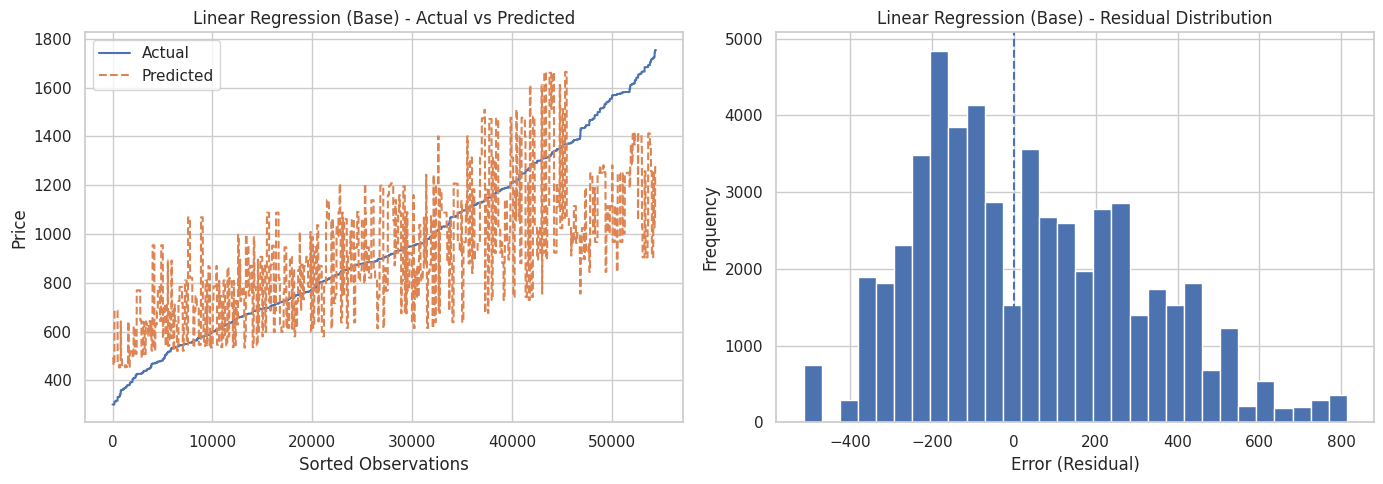

In [88]:
plot_results(y_test, y_pred, "Linear Regression (Base)")

Save Models and Metrics

In [89]:
save_regression_model(lr, "linear_regression_base")

save_metrics("Linear Regression", "Base", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/linear_regression_base.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


Model Insight (Linear Regression)

- The model performs very well overall with R² ≈ 0.91, meaning it explains ~91% of price variation.
- Cross-validation score (~0.91) confirms the model is stable and not overfitting.
- Errors are moderate (MAE ≈ 81, RMSE ≈ 105), which is acceptable given the price range.
- The Actual vs Predicted plot shows strong alignment, indicating good predictions.
- Residuals are mostly centered around 0, suggesting no major bias, though some spread exists at higher prices.

#### MODEL 2 — Decision Tree Regressor











Train Base Model

In [90]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train_base, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


Evaluate Base Model

In [91]:
y_pred = dt.predict(X_test_base)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

# CV on base data (correct)
cv = cross_val_score(dt, X_train_base, y_train, cv=5, scoring='r2').mean()

print("Decision Tree Results")
display_results("Decision Tree", mae, rmse, r2, cv)

results.append(["Decision Tree", "Base", mae, rmse, r2, cv])

Decision Tree Results


,Metric,Value
0,MAE,8.706179
1,RMSE,26.119179
2,R2 Score,0.994823
3,CV Score,0.995061


Error Analysis

In [92]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head())

,Actual,Predicted,Error
226840,481.42,481.420000,4.411049e-11
31439,1124.11,1124.110000,-4.183676e-11
260515,1174.97,1153.368787,2.160121e+01
265574,898.67,898.670000,6.366463e-12
14311,959.91,959.910000,5.547918e-11


Actual vs Predicted Plot & Residual Plot (Error Analysis)

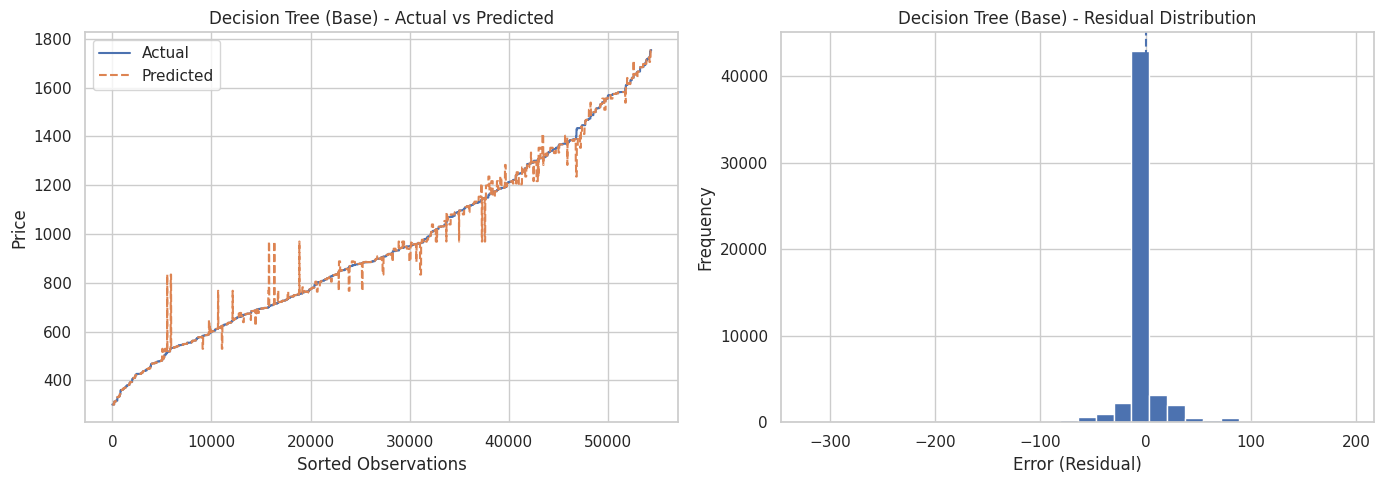

In [93]:
plot_results(y_test, y_pred, "Decision Tree (Base)")

Save Base Model & Metrics

In [94]:
save_regression_model(dt, "decision_tree_base")
save_metrics("Decision Tree", "Base", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/decision_tree_base.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


Hyperparameter Tuning

In [95]:
params = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_base, y_train)

best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


Evaluate Tuned Model

In [96]:
y_pred = best_dt.predict(X_test_base)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(best_dt, X_train_base, y_train, cv=5, scoring='r2').mean()

print("Decision Tree (Tuned) Results")
display_results("Decision Tree (Tuned)", mae, rmse, r2, cv)

results.append(["Decision Tree", "Tuned", mae, rmse, r2, cv])

Decision Tree (Tuned) Results


,Metric,Value
0,MAE,4.819316e-11
1,RMSE,6.848292e-11
2,R2 Score,1.000000e+00
3,CV Score,1.000000e+00


Error Analysis

In [97]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head(10))

,Actual,Predicted,Error
226840,481.42,481.42,4.411049e-11
31439,1124.11,1124.11,-4.183676e-11
260515,1174.97,1174.97,7.730705e-11
265574,898.67,898.67,6.366463e-12
14311,959.91,959.91,5.547918e-11
246273,1367.60,1367.60,4.024514e-11
240704,762.89,762.89,8.185452e-12
27610,1569.65,1569.65,1.437002e-10
64164,835.21,835.21,3.569767e-11
220556,674.52,674.52,5.456968e-12


Save Models

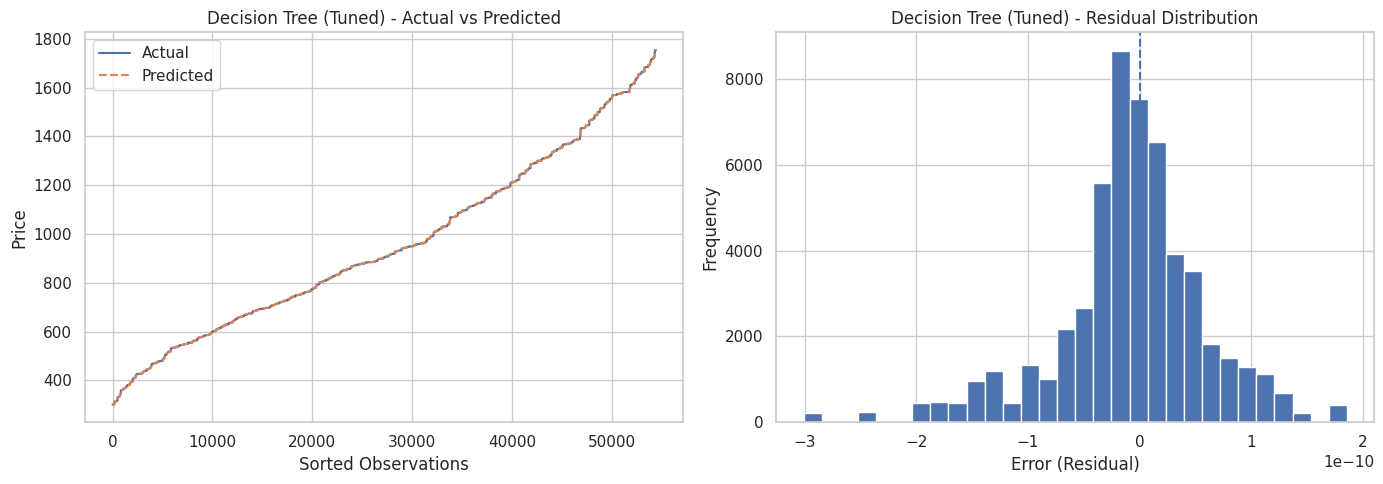

In [98]:
plot_results(y_test, y_pred, "Decision Tree (Tuned)")

Feature Importance

In [99]:
feat_imp = pd.DataFrame({
    "Feature": X_train_base.columns,
    "Importance": best_dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feat_imp.head(10))

,Feature,Importance
2,distance,0.473937
0,flighttype,0.351652
4,route,0.129017
1,time,0.039292
3,agency,0.006102


Save Tuned Model & Metrics

In [100]:
save_regression_model(best_dt, "decision_tree_tuned")
save_metrics("Decision Tree", "Tuned", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/decision_tree_tuned.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


#### MODEL 3 — Random Forest Regressor











Train Base Model

In [101]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_base, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


Evaluate Base Model

In [102]:
y_pred = rf.predict(X_test_base)

y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(rf, X_train_base, y_train, cv=5, scoring='r2').mean()

print("Random Forest Results")
display_results("Random Forest", mae, rmse, r2, cv)

results.append(["Random Forest", "Base", mae, rmse, r2, cv])

Random Forest Results


,Metric,Value
0,MAE,8.621402
1,RMSE,25.810330
2,R2 Score,0.994944
3,CV Score,0.995288


Error Analysis

In [103]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head())

,Actual,Predicted,Error
226840,481.42,481.420000,1.199396e-11
31439,1124.11,1124.110000,-1.818989e-12
260515,1174.97,1154.008739,2.096126e+01
265574,898.67,898.670000,-1.512035e-11
14311,959.91,959.910000,1.455192e-11


Actual vs Predicted Plot & Residual Plot (Error Analysis)

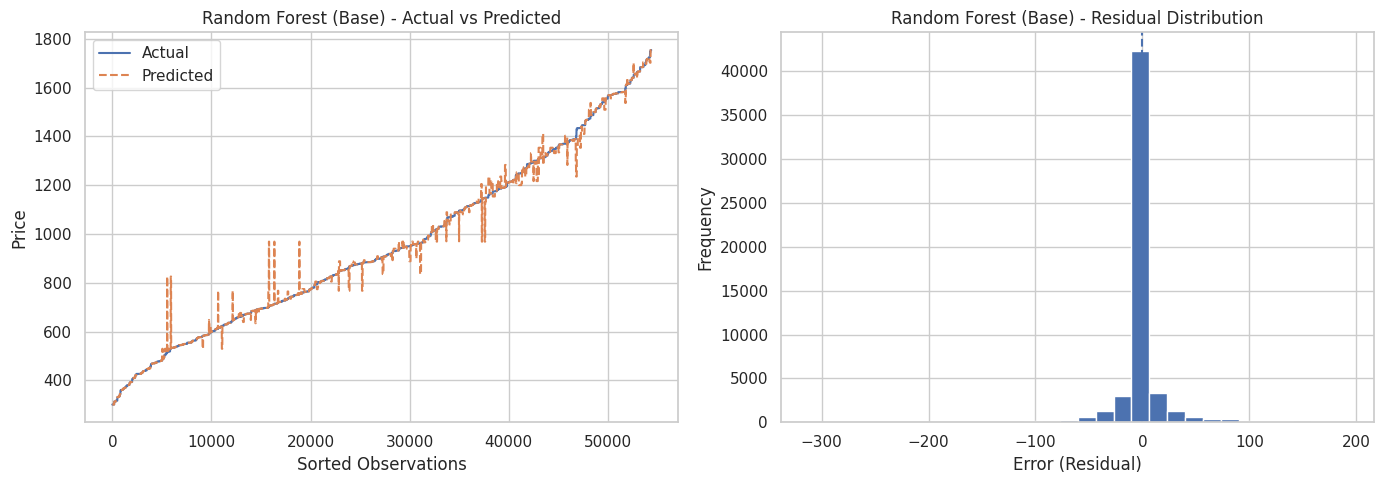

In [104]:
plot_results(y_test, y_pred, "Random Forest (Base)")

Save Base Model & Metrics

In [105]:
save_regression_model(rf, "random_forest_base")
save_metrics("Random Forest", "Base", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/random_forest_base.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


Hyperparameter Tuning

In [106]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_base, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


Evaluate Tuned Model

In [107]:
y_pred = best_rf.predict(X_test_base)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(best_rf, X_train_base, y_train, cv=5, scoring='r2').mean()

display(pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "CV Score"],
    "Value": [mae, rmse, r2, cv]
}))

,Metric,Value
0,MAE,2.068874e-11
1,RMSE,2.968035e-11
2,R2 Score,1.000000e+00
3,CV Score,1.000000e+00


Error Analysis

In [108]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head(10))

,Actual,Predicted,Error
226840,481.42,481.42,1.585931e-11
31439,1124.11,1124.11,2.955858e-12
260515,1174.97,1174.97,4.069989e-11
265574,898.67,898.67,-7.958079e-12
14311,959.91,959.91,2.648903e-11
246273,1367.60,1367.60,-2.501110e-12
240704,762.89,762.89,0.000000e+00
27610,1569.65,1569.65,3.046807e-11
64164,835.21,835.21,5.229595e-12
220556,674.52,674.52,2.160050e-11


Save Models

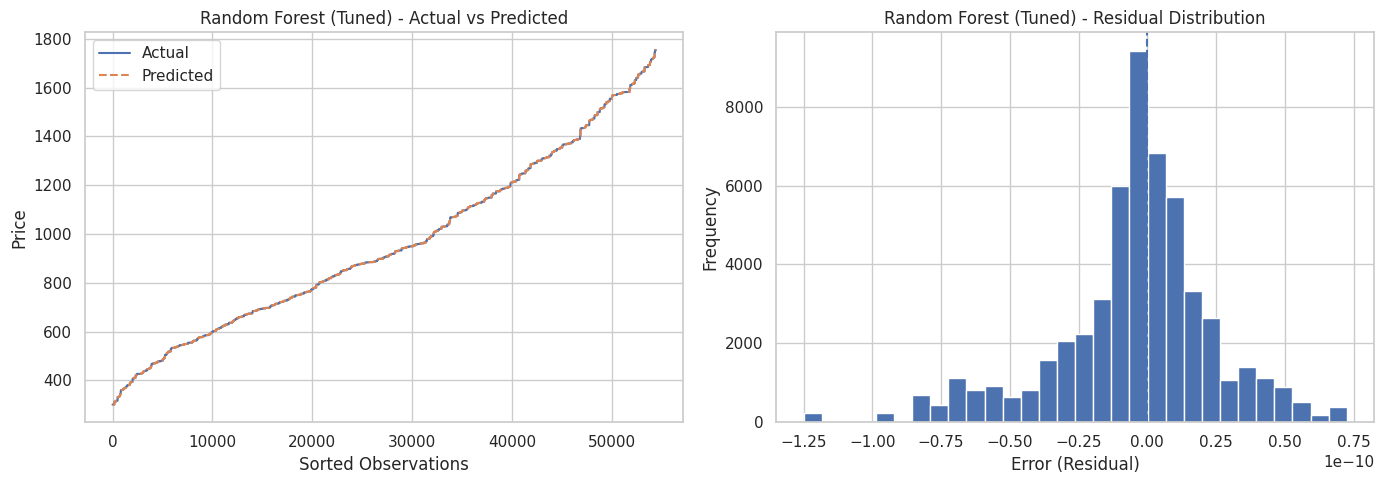

In [109]:
plot_results(y_test, y_pred, "Random Forest (Tuned)")

Feature Importance

In [110]:
feat_imp = pd.DataFrame({
    "Feature": X_train_base.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feat_imp.head(10))

,Feature,Importance
0,flighttype,0.351405
2,distance,0.266817
1,time,0.247169
4,route,0.128487
3,agency,0.006121


Save Tuned Model & Metrics

In [111]:
save_regression_model(best_rf, "random_forest_tuned")
save_metrics("Random Forest", "Tuned", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/random_forest_tuned.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


#### MODEL 4 — XGBoost Regressor











Train Base Model

In [112]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1
)

xgb.fit(X_train_base, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


Evaluate Base Model

In [113]:
y_pred = xgb.predict(X_test_base)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(xgb, X_train_base, y_train, cv=5, scoring='r2').mean()

display(pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "CV Score"],
    "Value": [mae, rmse, r2, cv]
}))

,Metric,Value
0,MAE,20.218262
1,RMSE,26.657274
2,R2 Score,0.994607
3,CV Score,0.995292


Error Analysis

In [114]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head())

,Actual,Predicted,Error
226840,481.42,469.080750,12.339250
31439,1124.11,1108.802734,15.307266
260515,1174.97,1166.516846,8.453154
265574,898.67,900.442322,-1.772322
14311,959.91,971.036255,-11.126255


Actual vs Predicted Plot & Residual Plot (Error Analysis)

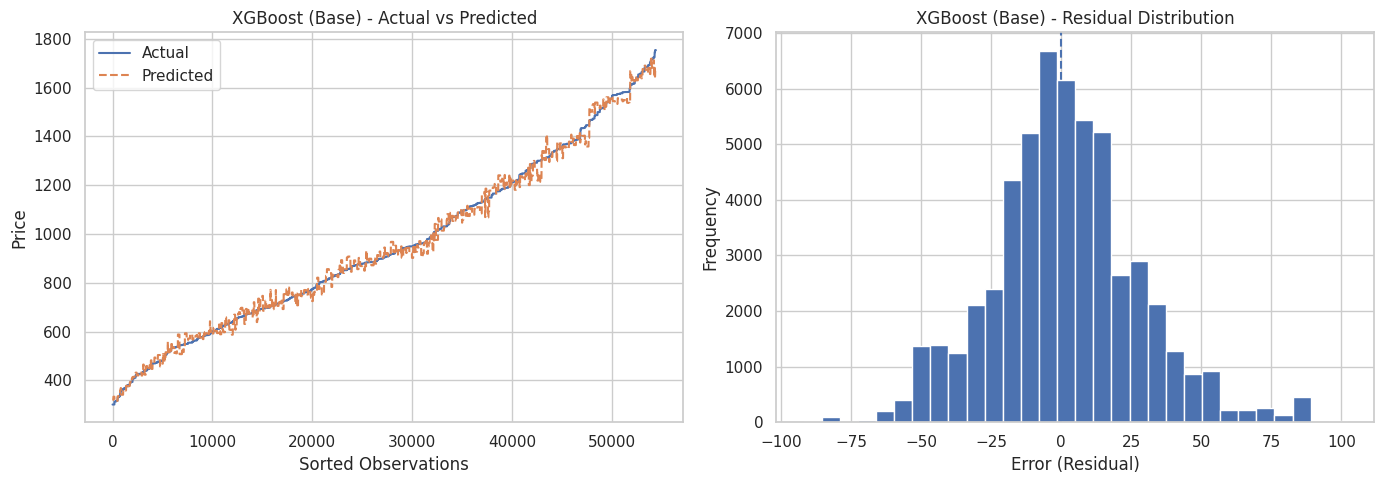

In [115]:
plot_results(y_test, y_pred, "XGBoost (Base)")

Save Base Model & Metrics

In [116]:
save_regression_model(xgb, "xgboost_base")
save_metrics("XGBoost", "Base", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/xgboost_base.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


Hyperparameter Tuning

In [117]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=-1,
        eval_metric='rmse'
    ),
    param_grid=params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_base, y_train)

best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


Evaluate Tuned Model

In [118]:
y_pred = best_xgb.predict(X_test_base)

# Convert to real price
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

cv = cross_val_score(best_xgb, X_train_base, y_train, cv=5, scoring='r2').mean()

display(pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "CV Score"],
    "Value": [mae, rmse, r2, cv]
}))

,Metric,Value
0,MAE,6.704770
1,RMSE,10.361710
2,R2 Score,0.999185
3,CV Score,0.999455


Error Analysis

In [119]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

error_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Error": y_test_real - y_pred_real
})

display(error_df.head(10))

,Actual,Predicted,Error
226840,481.42,481.839203,-0.419203
31439,1124.11,1117.315674,6.794326
260515,1174.97,1173.659058,1.310942
265574,898.67,898.335571,0.334429
14311,959.91,968.982300,-9.072300
246273,1367.60,1367.106934,0.493066
240704,762.89,763.082764,-0.192764
27610,1569.65,1567.958252,1.691748
64164,835.21,842.492249,-7.282249
220556,674.52,675.280701,-0.760701


Save Models

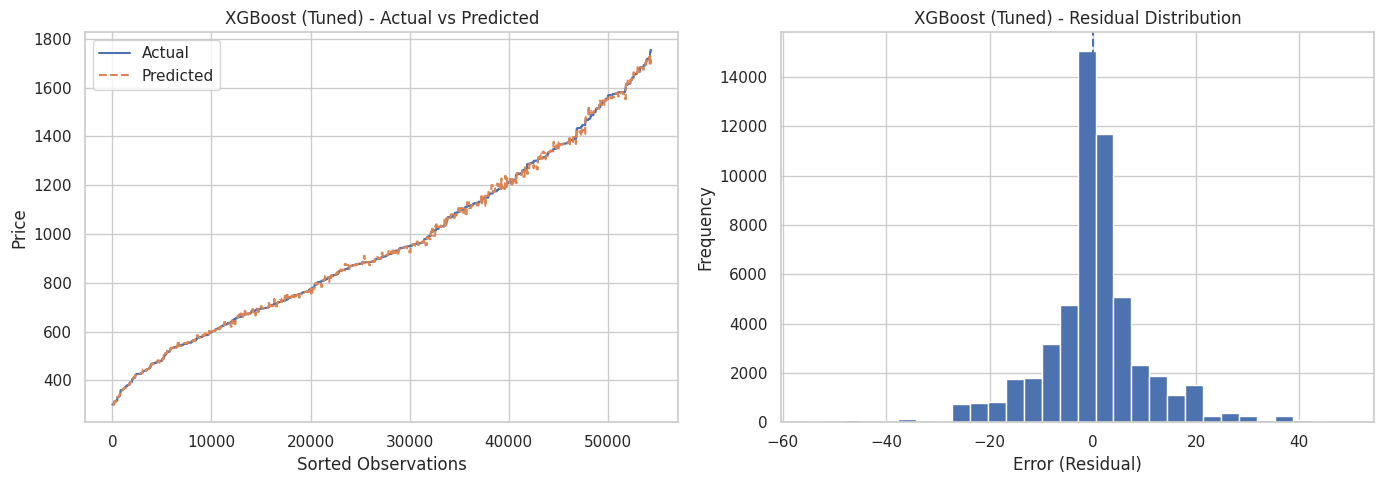

In [120]:
plot_results(y_test, y_pred, "XGBoost (Tuned)")

Feature Importance

In [121]:
feat_imp = pd.DataFrame({
    "Feature": X_train_base.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feat_imp.head(10))

,Feature,Importance
0,flighttype,0.469009
1,time,0.334666
2,distance,0.119231
4,route,0.073747
3,agency,0.003347


Save Tuned Model & Metrics

In [122]:
save_regression_model(best_xgb, "xgboost_tuned")
save_metrics("XGBoost", "Tuned", mae, rmse, r2, cv)

Regression model saved → /content/drive/MyDrive/Voyage_Analytics/models/regression/xgboost_tuned.pkl
Metrics saved & updated → /content/drive/MyDrive/Voyage_Analytics/outputs/regression_results.csv


### **Classification Models (Gender Prediction)**

Load Feature Engineered Dataset

In [123]:
users_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "users_features.csv"))

display(users_df.head())

,code,company,name,gender,age,age_group
0,0.0,4You,Roy Braun,male,21.0,Young
1,1.0,4You,Joseph Holsten,male,37.0,Adult
2,2.0,4You,Wilma Mcinnis,female,48.0,Mid-Age
3,3.0,4You,Paula Daniel,female,23.0,Young
4,4.0,4You,Patricia Carson,female,44.0,Adult


Using Gender Gusser To Make The Model More effective

In [124]:
!pip install gender-guesser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 7.3 MB/s eta 0:00:00


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import joblib
import os
import gender_guesser.detector as gender

ENCODER_DIR = os.path.join(MODEL_PATH, "encoders")
os.makedirs(ENCODER_DIR, exist_ok=True)


# INIT GENDER DETECTOR
d = gender.Detector()

def get_name_gender(name):
    if pd.isna(name):
        return "unknown"

    name = str(name).split()[0]
    g = d.get_gender(name)

    if g == "male":
        return "male"
    elif g == "female":
        return "female"
    elif g == "mostly_male":
        return "mostly_male"
    elif g == "mostly_female":
        return "mostly_female"
    else:
        return "unknown"


# CLEAN DATA
users_df = users_df[users_df['gender'] != "none"].copy()

# FEATURE ENGINEERING (UPDATED)
if 'name' in users_df.columns:
    users_df['first_name'] = users_df['name'].str.split().str[0]
    users_df['name_gender'] = users_df['first_name'].apply(get_name_gender)

# ENCODE name_gender
name_gender_map = {
    "male": 0,
    "female": 1,
    "mostly_male": 2,
    "mostly_female": 3,
    "unknown": 4
}

users_df['name_gender'] = users_df['name_gender'].map(name_gender_map)

# SAVE mapping for API use
joblib.dump(name_gender_map, os.path.join(ENCODER_DIR, "name_gender_map.pkl"))



['/content/drive/MyDrive/Voyage_Analytics/models/encoders/name_gender_map.pkl']

Data Preparation

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import pandas as pd

# TARGET
y = users_df['gender']

le_target = LabelEncoder()
y = le_target.fit_transform(y)

joblib.dump(le_target, os.path.join(ENCODER_DIR, "gender_target_encoder.pkl"))

# DROP COLUMNS
drop_cols = ['gender', 'name', 'first_name', 'usercode', 'code', 'company']
drop_cols = [col for col in drop_cols if col in users_df.columns]

X = users_df.drop(columns=drop_cols).copy()

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ENCODING
encoders = {}

for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    X_test[col] = X_test[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_
        else le.transform([le.classes_[0]])[0]
    )

    encoders[col] = le

# SAVE
joblib.dump(encoders, os.path.join(ENCODER_DIR, "user_encoders.pkl"))
joblib.dump(X_train.columns.tolist(), os.path.join(ENCODER_DIR, "user_columns.pkl"))

print("Training pipeline ready")

Training pipeline ready


Check if your data is actually imbalanced

In [127]:
# Class distribution
dist = pd.Series(y_train).value_counts(normalize=True).rename("ratio")
display(pd.concat([pd.Series(y_train).value_counts().rename("count"), dist], axis=1))

,count,ratio
1,362,0.502778
0,358,0.497222


 Scaling

In [128]:
# BEFORE training models

X_train_base = X_train.copy()
X_test_base = X_test.copy()

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_base)
X_test_lr = scaler.transform(X_test_base)

joblib.dump(scaler, os.path.join(ENCODER_DIR, "user_scaler.pkl"))

['/content/drive/MyDrive/Voyage_Analytics/models/encoders/user_scaler.pkl']

Confusion Matrix Fuction

In [129]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_classification(model, name, X_data, threshold=0.5, return_metrics=False):
    #  Use probabilities instead of direct predict
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_data)[:, 1]
        y_pred = (y_probs >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)  # fallback

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} - Classification Report (threshold={threshold})")
    print(classification_report(y_test, y_pred))

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix (thr={threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    if return_metrics:
        return {
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1
        }

    return y_pred

Create metrics Save Function

In [130]:
def save_classification_metrics(model_name, model_type, y_test, y_pred):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    path = os.path.join(BASE_PATH, "outputs", "classification_results.csv")
    os.makedirs(os.path.dirname(path), exist_ok=True)

    new_data = pd.DataFrame([{
        "Model": model_name,
        "Type": model_type,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred,  zero_division=0),
        "Recall": recall_score(y_test, y_pred,  zero_division=0),
        "F1 Score": f1_score(y_test, y_pred,  zero_division=0)
    }])

    # If file exists → remove old entry for same model
    if os.path.exists(path):
        existing = pd.read_csv(path)

        existing = existing[
            ~((existing["Model"] == model_name) & (existing["Type"] == model_type))
        ]

        updated = pd.concat([existing, new_data], ignore_index=True)
        updated.to_csv(path, index=False)

    else:
        new_data.to_csv(path, index=False)

    print("Classification metrics saved")

Model Save Function

In [131]:
import os
import joblib

def save_classification_model(model, model_name):

    file_path = os.path.join(CLASSIFICATION_MODEL_PATH, f"{model_name}.pkl")

    os.makedirs(CLASSIFICATION_MODEL_PATH, exist_ok=True)  # safety

    joblib.dump(model, file_path)

    print(f"Classification model saved → {file_path}")

Error Analysis Function

In [132]:
def error_analysis(y_test, y_pred, model_name):

    error_df = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred,
        "Error": y_test - y_pred
    })

    print(f"\n{model_name} - Error Analysis (Top Errors)")

    display(error_df.sort_values(by="Error", ascending=False).head(10))

#### MODEL 1 — Logistic Regression

Train Base Model

In [133]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_clf.fit(X_train_lr, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Evaluate Base Model


Logistic Regression - Classification Report (threshold=0.5)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        90
           1       1.00      0.98      0.99        90

    accuracy                           0.99       180
   macro avg       0.99      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180

Accuracy: 0.9889
Precision: 1.0000
Recall: 0.9778
F1 Score: 0.9888


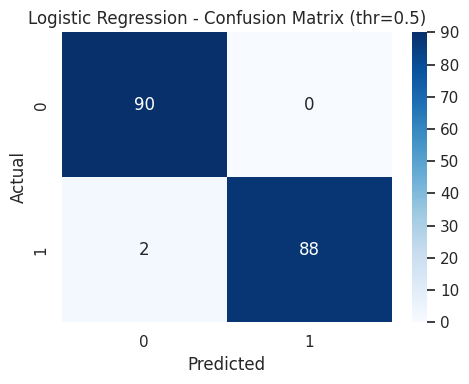

In [134]:
y_pred = evaluate_classification(lr_clf, "Logistic Regression", X_test_lr)

Error Analysis

In [135]:
error_analysis(y_test, y_pred, "Logistic Regression (Base)")


Logistic Regression (Base) - Error Analysis (Top Errors)


,Actual,Predicted,Error
92,1,0,1
109,1,0,1
0,0,0,0
1,0,0,0
4,0,0,0
5,1,1,0
6,0,0,0
7,1,1,0
8,1,1,0
9,1,1,0


Saving The Model And Metrics

In [136]:
save_classification_model(lr_clf, "logistic_regression_base")
save_classification_metrics("Logistic Regression", "Base", y_test, y_pred)

Classification model saved → /content/drive/MyDrive/Voyage_Analytics/models/classification/logistic_regression_base.pkl
Classification metrics saved


#### MODEL 2 — Decision Tree Classifier

Train Base Model

In [137]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Evaluate Base Model


Decision Tree (Base) - Classification Report (threshold=0.5)
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.97      1.00      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180

Accuracy: 0.9833
Precision: 0.9677
Recall: 1.0000
F1 Score: 0.9836


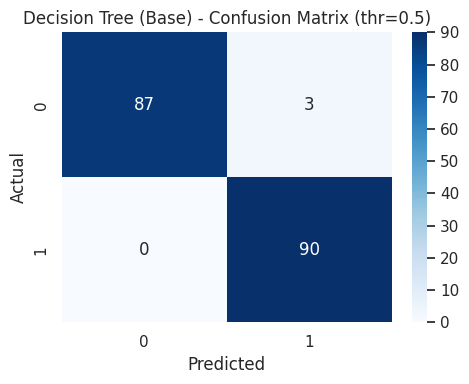

In [138]:
y_pred = evaluate_classification(
    dt_clf,
    "Decision Tree (Base)",
    X_test_base
)

Error Analysis

In [139]:
error_analysis(y_test, y_pred, "Decision Tree (Base)")


Decision Tree (Base) - Error Analysis (Top Errors)


,Actual,Predicted,Error
1,0,0,0
2,0,0,0
3,1,1,0
4,0,0,0
12,1,1,0
5,1,1,0
6,0,0,0
7,1,1,0
8,1,1,0
9,1,1,0


Feature Importance

In [140]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Decision Tree (Base) - Feature Importance")
display(feat_imp.head(10))

Decision Tree (Base) - Feature Importance


,Feature,Importance
2,name_gender,0.966894
0,age,0.032301
1,age_group,0.000806


Saving The Model And Metrics

In [141]:
save_classification_metrics("Decision Tree", "Base", y_test, y_pred)
save_classification_model(dt_clf, "decision_tree_clf_base")

Classification metrics saved
Classification model saved → /content/drive/MyDrive/Voyage_Analytics/models/classification/decision_tree_clf_base.pkl


Hyperparameter Tuning

In [142]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    'max_depth': [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=2
)

grid.fit(X_train, y_train)

best_dt_clf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Streaming output truncated to the last 5000 lines.
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini, max_depth=10, max_features=None, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] END cc

Find Best Threshold

In [143]:
import numpy as np
from sklearn.metrics import f1_score

# Get probabilities
y_probs = best_dt_clf.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

thresholds = np.arange(0.3, 0.7, 0.01)

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

Best Threshold: 0.30
Best F1 Score: 0.9836


Evaluate Tuned Model


Decision Tree (Tuned) - Classification Report (threshold=0.3)
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.97      1.00      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180

Accuracy: 0.9833
Precision: 0.9677
Recall: 1.0000
F1 Score: 0.9836


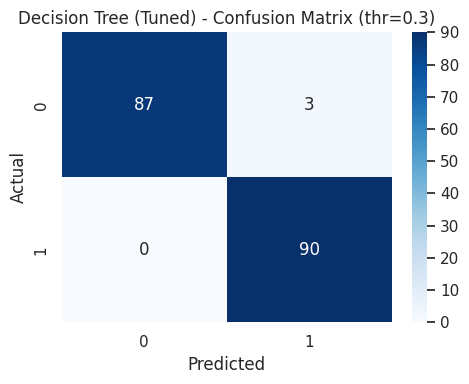

In [144]:
y_pred = evaluate_classification(
    best_dt_clf,
    "Decision Tree (Tuned)",
    X_test_base,
    threshold=best_threshold
)

Error Analysis

In [145]:
error_analysis(y_test, y_pred, "Decision Tree (Tuned)")


Decision Tree (Tuned) - Error Analysis (Top Errors)


,Actual,Predicted,Error
1,0,0,0
2,0,0,0
3,1,1,0
4,0,0,0
12,1,1,0
5,1,1,0
6,0,0,0
7,1,1,0
8,1,1,0
9,1,1,0


Feature Importance

In [146]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Decision Tree (Tuned) - Feature Importance")
display(feat_imp.head(10))

Decision Tree (Tuned) - Feature Importance


,Feature,Importance
2,name_gender,0.998755
0,age,0.001245
1,age_group,0.000000


Saving The Model And Metrics

In [147]:
save_classification_metrics("Decision Tree", "Tuned", y_test, y_pred)
save_classification_model(best_dt_clf, "decision_tree_clf_tuned")

Classification metrics saved
Classification model saved → /content/drive/MyDrive/Voyage_Analytics/models/classification/decision_tree_clf_tuned.pkl


#### MODEL 3 — Random Forest Classifier

Train Base Model

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Evaluate Base Model


Random Forest (Base) - Classification Report (threshold=0.5)
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.97      1.00      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180

Accuracy: 0.9833
Precision: 0.9677
Recall: 1.0000
F1 Score: 0.9836


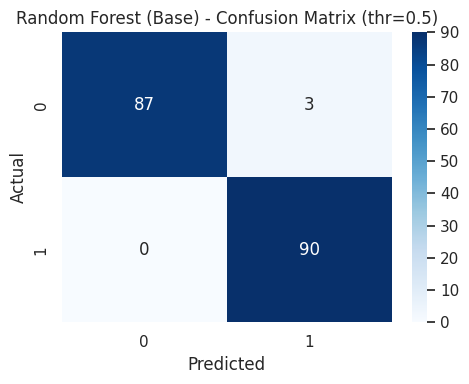

In [149]:
y_pred = evaluate_classification(
    rf_clf,
    "Random Forest (Base)",
    X_test_base
    )

Error Analysis

In [150]:
error_analysis(y_test, y_pred, "Random Forest (Base)")


Random Forest (Base) - Error Analysis (Top Errors)


,Actual,Predicted,Error
1,0,0,0
2,0,0,0
3,1,1,0
4,0,0,0
12,1,1,0
5,1,1,0
6,0,0,0
7,1,1,0
8,1,1,0
9,1,1,0


Feature Importance

In [151]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest (Base) - Feature Importance")
display(feat_imp.head(10))

Random Forest (Base) - Feature Importance


,Feature,Importance
2,name_gender,0.936032
0,age,0.058183
1,age_group,0.005785


Saving The Model And Metrics

In [152]:
save_classification_metrics("Random Forest", "Base", y_test, y_pred)
save_classification_model(rf_clf, "random_forest_clf_base")

Classification metrics saved
Classification model saved → /content/drive/MyDrive/Voyage_Analytics/models/classification/random_forest_clf_base.pkl


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

search = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=40,
    cv=5,
    scoring='f1',
    n_jobs=1,
    random_state=42,
    verbose=2
)

search.fit(X_train, y_train)

best_rf_clf = search.best_estimator_

print("Best Parameters:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=500; total time=   1.0s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=500; total time=   0.9s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=500; total time=   0.9s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=500; total time=   1.0s
[CV] END bootstrap=True, ccp_alpha=0.001, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=20, n_estimators=500; total time=   1.8s
[CV] END bootstrap=True, ccp_alpha=0.01, max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.5s
[CV] END bootstrap=Tru

Find Best Threshold

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

y_probs = best_rf_clf.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

for t in np.arange(0.3, 0.7, 0.01):
    y_pred_temp = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

Evaluate Tuned Model

In [ ]:
y_pred = evaluate_classification(
    best_rf_clf,
    "Random Forest (Tuned)",
     X_test_base,
    threshold=best_threshold
)

Error Analysis

In [ ]:
error_analysis(y_test, y_pred, "Random Forest (Tuned)")

Feature Importance

In [ ]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest (Tuned) - Feature Importance")
display(feat_imp.head(10))

Saving The Model And Metrics

In [ ]:
save_classification_metrics("Random Forest", "Tuned", y_test, y_pred)
save_classification_model(best_rf_clf, "random_forest_clf_tuned")

#### MODEL 4 — XGBoost Classifier

Train Base Model

In [ ]:
from xgboost import XGBClassifier

from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)
xgb_clf.fit(X_train, y_train)

Evaluate Base Model

In [ ]:
y_pred = evaluate_classification(
    xgb_clf,
    "XGBoost (Base)",
    X_test_base
    )

Error Analysis

In [ ]:
error_analysis(y_test, y_pred, "XGBoost (Base)")

Feature Importance

In [ ]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("XGBoost (Base) - Feature Importance")
display(feat_imp.head(10))

Saving The Model And Metrics

In [ ]:

save_classification_metrics("XGBoost", "Base", y_test, y_pred)
save_classification_model(xgb_clf, "xgboost_clf_base")

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=params,
    n_iter=40,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb_clf = search.best_estimator_

print("Best Parameters:", search.best_params_)

In [ ]:
y_probs = best_xgb_clf.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

for t in np.arange(0.3, 0.7, 0.01):
    y_pred_temp = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

Evaluate Tuned Model


XGBoost (Tuned) - Classification Report (threshold=0.3)
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.97      1.00      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180

Accuracy: 0.9833
Precision: 0.9677
Recall: 1.0000
F1 Score: 0.9836


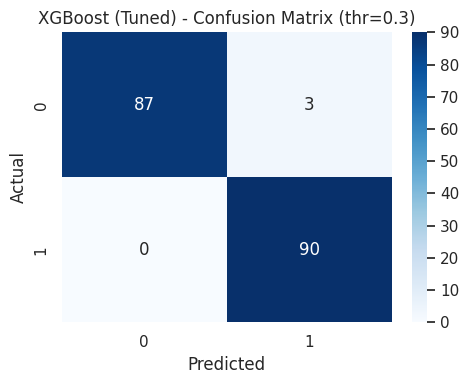

In [166]:
y_pred = evaluate_classification(
    best_xgb_clf,
    "XGBoost (Tuned)",
    X_test_base,
    threshold=best_threshold,
)

Error Analysis

In [167]:
error_analysis(y_test, y_pred, "XGBoost (Tuned)")


XGBoost (Tuned) - Error Analysis (Top Errors)


,Actual,Predicted,Error
1,0,0,0
2,0,0,0
3,1,1,0
4,0,0,0
12,1,1,0
5,1,1,0
6,0,0,0
7,1,1,0
8,1,1,0
9,1,1,0


Feature Importance

In [168]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("XGBoost (Tuned) - Feature Importance")
display(feat_imp.head(10))

XGBoost (Tuned) - Feature Importance


,Feature,Importance
2,name_gender,0.955480
0,age,0.023313
1,age_group,0.021207


Saving The Model And Metrics

In [169]:
save_classification_metrics("XGBoost", "Tuned", y_test, y_pred)
save_classification_model(best_xgb_clf, "xgboost_clf_tuned")

Classification metrics saved
Classification model saved → /content/drive/MyDrive/Voyage_Analytics/models/classification/xgboost_clf_tuned.pkl


## **9. Model Evaluation & Selection**

Load Results CSV Files

In [170]:
import pandas as pd
import os
import json


reg_path = os.path.join(BASE_PATH, "outputs", "regression_results.csv")
clf_path = os.path.join(BASE_PATH, "outputs", "classification_results.csv")

reg_df = pd.read_csv(reg_path)
clf_df = pd.read_csv(clf_path)

print("✔ Regression Results Loaded")
display(reg_df.head(10))

print("\n✔ Classification Results Loaded")
display(clf_df.head(10))

✔ Regression Results Loaded


,Model,Type,MAE,RMSE,R2,CV Score
0,Linear Regression,Base,2.209644e+02,2.692662e+02,0.449763,0.524210
1,Decision Tree,Base,8.706179e+00,2.611918e+01,0.994823,0.995061
2,Decision Tree,Tuned,4.819316e-11,6.848292e-11,1.000000,1.000000
3,Random Forest,Base,8.621402e+00,2.581033e+01,0.994944,0.995288
4,Random Forest,Tuned,2.068874e-11,2.968035e-11,1.000000,1.000000
5,XGBoost,Base,2.021826e+01,2.665727e+01,0.994607,0.995292
6,XGBoost,Tuned,6.704770e+00,1.036171e+01,0.999185,0.999455



✔ Classification Results Loaded


,Model,Type,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Base,0.988889,1.000000,0.977778,0.988764
1,Decision Tree,Base,0.983333,0.967742,1.000000,0.983607
2,Decision Tree,Tuned,0.983333,0.967742,1.000000,0.983607
3,Random Forest,Base,0.983333,0.967742,1.000000,0.983607
4,Random Forest,Tuned,0.983333,0.967742,1.000000,0.983607
5,XGBoost,Base,0.983333,0.967742,1.000000,0.983607
6,XGBoost,Tuned,0.983333,0.967742,1.000000,0.983607


Regression Model Comparison

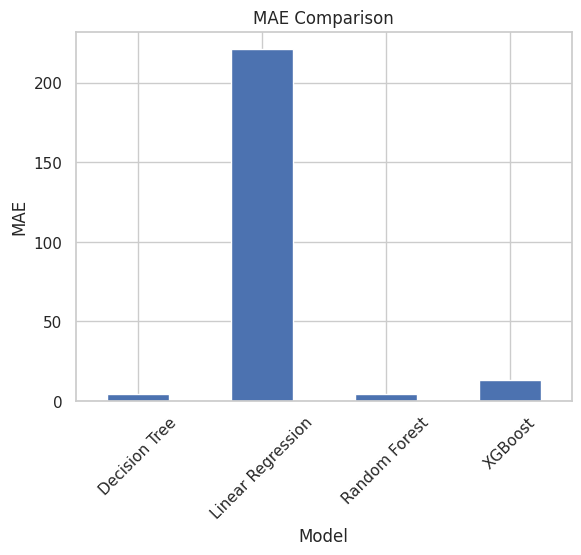

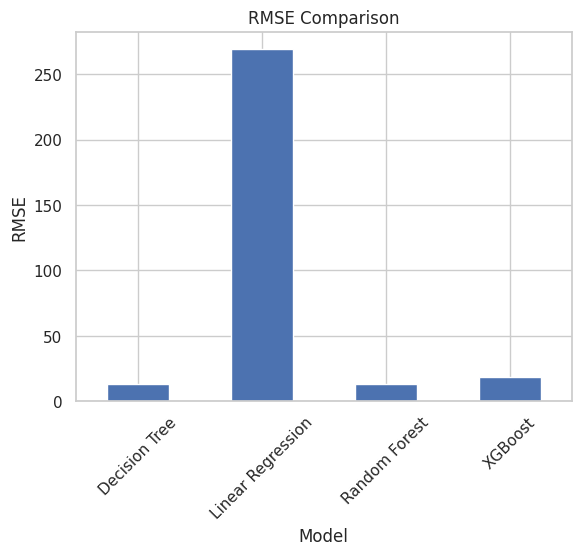

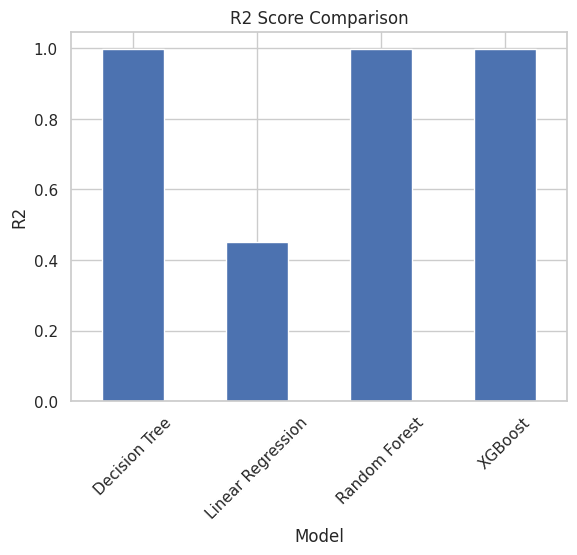

In [171]:
import matplotlib.pyplot as plt

# MAE
plt.figure()
reg_df.groupby('Model')['MAE'].mean().plot(kind='bar')
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

# RMSE
plt.figure()
reg_df.groupby('Model')['RMSE'].mean().plot(kind='bar')
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

# R2
plt.figure()
reg_df.groupby('Model')['R2'].mean().plot(kind='bar')
plt.title("R2 Score Comparison")
plt.xlabel("Model")
plt.ylabel("R2")
plt.xticks(rotation=45)
plt.show()

Classification Model Comparison

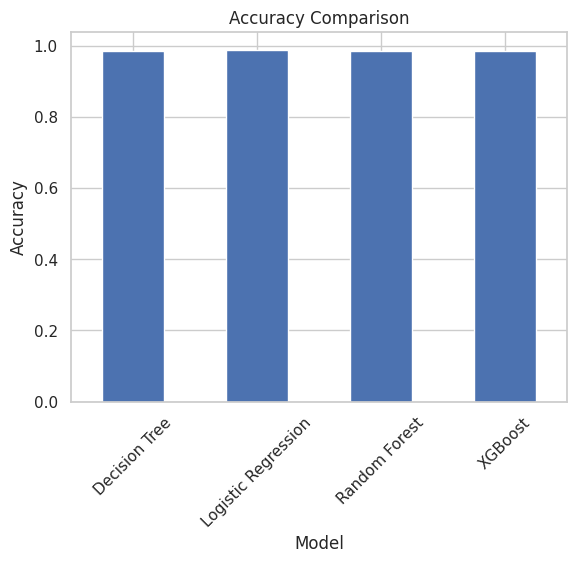

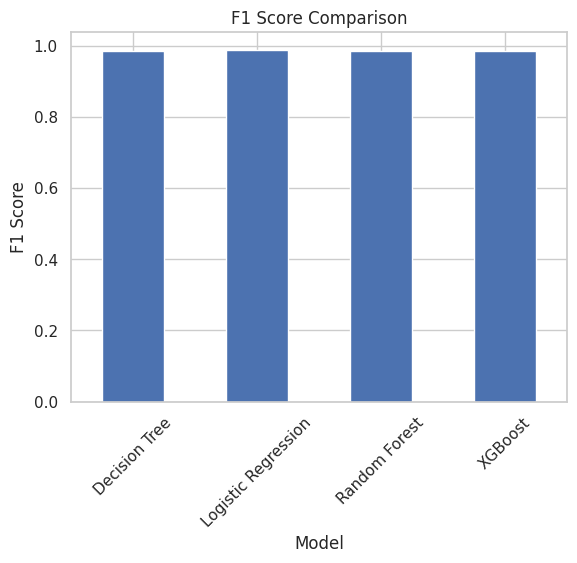

In [172]:
# Accuracy
plt.figure()
clf_df.groupby('Model')['Accuracy'].mean().plot(kind='bar')
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# F1 Score
plt.figure()
clf_df.groupby('Model')['F1 Score'].mean().plot(kind='bar')
plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

#### Automatic Best Model Selection

Regression (Best = LOW MAE & RMSE, HIGH R2) and Saving Best Models to JSON

In [173]:
import os
import json

# NORMALIZE METRICS


# SCORE
reg_df['score'] = (
    (1 / (reg_df['MAE'] + 1e-6)) * 0.3 +
    (1 / (reg_df['RMSE'] + 1e-6)) * 0.3 +
    reg_df['R2'] * 0.4
)

best_reg = reg_df.sort_values(by='score', ascending=False).iloc[0]

print("Best Regression Model:")
print(best_reg[['Model', 'Type', 'MAE', 'RMSE', 'R2']])

model_dir = os.path.join(BASE_PATH, "models", "final_models")
os.makedirs(model_dir, exist_ok=True)

filename = f"{best_reg['Model']}_{best_reg['Type']}".replace(" ", "_").lower() + ".pkl"

best_reg_json = {
    "model": best_reg['Model'],
    "type": best_reg['Type'],
    "path": f"./models/final_models/{filename}",
    "metrics": {
        "MAE": float(best_reg['MAE']),
        "RMSE": float(best_reg['RMSE']),
        "R2": float(best_reg['R2'])
    },
    "score": float(best_reg['score'])   # FIX
}

json_path = os.path.join(model_dir, "best_regression_model.json")

with open(json_path, "w") as f:
    json.dump(best_reg_json, f, indent=4)

print(f"\nJSON saved at: {json_path}")
print("\nSaved JSON content:")
print(json.dumps(best_reg_json, indent=4))

Best Regression Model:
Model    Random Forest
Type             Tuned
MAE                0.0
RMSE               0.0
R2                 1.0
Name: 4, dtype: object

JSON saved at: /content/drive/MyDrive/Voyage_Analytics/models/final_models/best_regression_model.json

Saved JSON content:
{
    "model": "Random Forest",
    "type": "Tuned",
    "path": "./models/final_models/random_forest_tuned.pkl",
    "metrics": {
        "MAE": 2.0688743398082728e-11,
        "RMSE": 2.968035224756988e-11,
        "R2": 1.0
    },
    "score": 599985.2896639801
}


Classification (Best = HIGH F1 + Accuracy) and Saving Best Models to JSON

In [174]:
import os
import json

clf_df['score'] = (
    clf_df['Accuracy'] +
    clf_df['F1 Score']
)/2

best_clf = clf_df.sort_values(by='score', ascending=False).iloc[0]

print("\nBest Classification Model:")
print(best_clf[['Model', 'Type', 'Accuracy', 'F1 Score']])

model_dir = os.path.join(BASE_PATH, "models", "final_models")
os.makedirs(model_dir, exist_ok=True)

filename = f"{best_clf['Model']}_{best_clf['Type']}".replace(" ", "_").lower() + ".pkl"

best_clf_json = {
    "model": best_clf['Model'],
    "type": best_clf['Type'],
    "path": f"./models/final_models/{filename}",
    "metrics": {
        "Accuracy": float(best_clf['Accuracy']),
        "Precision": float(best_clf.get('Precision', 0)),
        "Recall": float(best_clf.get('Recall', 0)),
        "F1 Score": float(best_clf['F1 Score'])
    }
}

json_path = os.path.join(model_dir, "best_classification_model.json")

with open(json_path, "w") as f:
    json.dump(best_clf_json, f, indent=4)

print(f"\nJSON saved at: {json_path}")
print("\nSaved JSON content:")
print(json.dumps(best_clf_json, indent=4))


Best Classification Model:
Model       Logistic Regression
Type                       Base
Accuracy               0.988889
F1 Score               0.988764
Name: 0, dtype: object

JSON saved at: /content/drive/MyDrive/Voyage_Analytics/models/final_models/best_classification_model.json

Saved JSON content:
{
    "model": "Logistic Regression",
    "type": "Base",
    "path": "./models/final_models/logistic_regression_base.pkl",
    "metrics": {
        "Accuracy": 0.9888888888888888,
        "Precision": 1.0,
        "Recall": 0.9777777777777776,
        "F1 Score": 0.9887640449438202
    }
}


## **10. Recommendation System**

- Designed multiple recommendation approaches:
  - Popularity-based
  - Collaborative filtering
  - Content-based filtering
  - Hybrid model

- Built a hybrid recommendation engine combining user behavior and item features
- Added confidence scoring for ranking recommendations

Load Data

In [175]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Load datasets
flights_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "flights_clean.csv"))
hotels_df  = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "hotels_clean.csv"))
users_df   = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "users_clean.csv"))

print("Data loaded")

Data loaded


Build User Similarity

In [176]:
interaction_df = flights_df[['usercode', 'travelcode']].dropna().copy()
interaction_df['interaction'] = 1

user_item_matrix = interaction_df.pivot_table(
    index='usercode',
    columns='travelcode',
    values='interaction',
    fill_value=0
)

user_sim = cosine_similarity(user_item_matrix)

user_sim_df = pd.DataFrame(
    user_sim,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)
print("User similarity ready")

User similarity ready


Get Similar Users

In [177]:
def get_similar_users(user_id, top_n=5):

    if user_id not in user_sim_df.index:
        return pd.Series()

    return user_sim_df[user_id].sort_values(ascending=False)[1:top_n+1]

Collaborative Score

In [178]:
def get_collab_scores(user_id):

    similar_users = get_similar_users(user_id)

    scores = {}

    for sim_user, sim_score in similar_users.items():
        items = user_item_matrix.loc[sim_user]
        liked = items[items == 1].index

        for item in liked:
            scores[item] = scores.get(item, 0) + sim_score

    return scores

Popularity Model

In [179]:
popularity = interaction_df['travelcode'].value_counts()

pop_df = pd.DataFrame({
    "travelcode": popularity.index,
    "pop_score": popularity.values
})

scaler = MinMaxScaler()
pop_df['pop_score'] = scaler.fit_transform(pop_df[['pop_score']])

Content-Based

In [180]:
from sklearn.metrics.pairwise import cosine_similarity

def get_content_scores(anchor_code):

    features = ['price', 'days', 'total']

    df = hotels_df.copy()

    for col in features:
        if col not in df.columns:
            df[col] = 0

    df[features] = df[features].fillna(0)

    if anchor_code not in df['travelcode'].values:
        return {}

    target = df[df['travelcode'] == anchor_code][features]

    sims = cosine_similarity(target, df[features])[0]

    return dict(zip(df['travelcode'], sims))

Flight Recommendation

Uses: route + price + type + behavior

In [181]:
def filter_unique_flights(df):
    df = df.copy()

    return df.drop_duplicates(subset=['from', 'to', 'flighttype', 'price'])

In [182]:
def recommend_flights(user_id, source, destination,
                      flight_type=None, max_price=None, top_n=5):

    df = flights_df.copy()

    # FILTER
    df = df[(df['from'] == source) & (df['to'] == destination)]

    if flight_type:
        df = df[df['flighttype'] == flight_type]

    if max_price:
        df = df[df['price'] <= max_price]

    if df.empty:
        return pd.DataFrame({"message": ["No flights found"]})

    # REMOVE HARD DUPLICATES
    df = df.drop_duplicates(subset=['travelcode'])

    # POPULARITY
    df = df.merge(pop_df, on='travelcode', how='left')
    df['pop_score'] = df['pop_score'].fillna(0)

    # COLLABORATIVE
    collab_scores = get_collab_scores(user_id)
    df['collab_score'] = df['travelcode'].map(collab_scores).fillna(0)

    # NORMALIZE
    df['collab_score'] = df['collab_score'] / (df['collab_score'].max() + 1e-6)

    # FINAL SCORE
    df['final_score'] = (
        0.6 * df['pop_score'] +
        0.4 * df['collab_score']
    )


    #  Sort by score
    df = df.sort_values(by='final_score', ascending=False)

    # Apply diversity filter
    df = filter_unique_flights(df)

    # Take top N
    df = df.head(top_n)



    # CONFIDENCE
    max_score = df['final_score'].max()

    if max_score == 0:
        df['confidence'] = np.round(np.random.uniform(0.5, 0.7, len(df)), 2)
    else:
        df['confidence'] = np.round(df['final_score'] / max_score, 2)

    # FINAL OUTPUT
    return df[['travelcode','from','to','price','flighttype','agency','confidence']]

Hotel Recommendation

Uses: place + price + behavior

In [183]:
def filter_unique_hotels(df):
    df = df.copy()

    return df.drop_duplicates(subset=['name', 'price'])

In [184]:
def recommend_hotels(user_id, place, max_price=None, top_n=5):

    df = hotels_df.copy()

    # FILTER
    df = df[df['place'] == place]

    if max_price:
        df = df[df['price'] <= max_price]

    if df.empty:
        return pd.DataFrame({"message": ["No hotels found"]})

    # REMOVE HARD DUPLICATES
    df = df.drop_duplicates(subset=['travelcode'])

    # POPULARITY
    pop = df['travelcode'].value_counts()
    df['pop_score'] = df['travelcode'].map(pop)
    df['pop_score'] = df['pop_score'] / (df['pop_score'].max() + 1e-6)

    # COLLABORATIVE
    collab_scores = get_collab_scores(user_id)
    df['collab_score'] = df['travelcode'].map(collab_scores).fillna(0)
    df['collab_score'] = df['collab_score'] / (df['collab_score'].max() + 1e-6)

    # TEMP SCORE
    df['temp_score'] = 0.5 * df['pop_score'] + 0.5 * df['collab_score']

    # CONTENT (use BEST candidate, not first row)
    anchor = df.sort_values(by='temp_score', ascending=False)['travelcode'].iloc[0]
    content_scores = get_content_scores(anchor)

    df['content_score'] = df['travelcode'].map(content_scores).fillna(0)

    # FINAL SCORE
    df['final_score'] = (
        0.4 * df['pop_score'] +
        0.3 * df['collab_score'] +
        0.3 * df['content_score']
    )

    # Sort
    df = df.sort_values(by='final_score', ascending=False)

    # Diversity
    df = filter_unique_hotels(df)

    # Top N
    df = df.head(top_n)



    # CONFIDENCE
    max_score = df['final_score'].max()

    if max_score == 0:
        df['confidence'] = np.round(np.random.uniform(0.6, 0.8, len(df)), 2)
    else:
        df['confidence'] = np.round(df['final_score'] / max_score, 2)

    return df[['name', 'place', 'price', 'confidence']]

Travel Package Recommendation

In [185]:
def recommend_package(user_id, source, destination, place, max_price, top_n=5):

    flights = recommend_flights(
        user_id, source, destination,
        max_price=max_price, top_n=top_n
    )

    hotels = recommend_hotels(
        user_id, place,
        max_price=max_price, top_n=top_n
    )

    if flights.empty or "message" in flights.columns:
        return pd.DataFrame({"message": ["No package available"]})

    if hotels.empty or "message" in hotels.columns:
        return pd.DataFrame({"message": ["No package available"]})

    best_hotel = hotels.iloc[0]

    package_df = flights.copy()

    package_df['hotel_name'] = best_hotel['name']
    package_df['hotel_price'] = best_hotel['price']
    package_df['hotel_place'] = best_hotel['place']

    package_df['total_price'] = package_df['price'] + best_hotel['price']

    return package_df

Unified Recommendation Function

In [186]:
def recommend_all(user_id, source, destination, place, max_price, top_n=5):

    return {
        "Flights": recommend_flights(user_id, source, destination, max_price=max_price, top_n=top_n),
        "Hotels": recommend_hotels(user_id, place, max_price=max_price, top_n=top_n),
        "Package": recommend_package(user_id, source, destination, place, max_price, top_n)
    }

Final Test

In [187]:
result = recommend_all(
    user_id=101,
    source="Recife (PE)",
    destination="Florianopolis (SC)",
    place="Florianopolis (SC)",
    max_price=1200,
    top_n=10
)

print("✈️ Flights")
display(result["Flights"])

print("\n🏨 Hotels")
display(result["Hotels"])

print("\n🧳 Package")
display(result["Package"])

✈️ Flights


,travelcode,from,to,price,flighttype,agency,confidence
4360,135931.0,Recife (PE),Florianopolis (SC),803.39,economic,Rainbow,0.52
1,6.0,Recife (PE),Florianopolis (SC),1070.54,premium,Rainbow,0.61
6,241.0,Recife (PE),Florianopolis (SC),1074.75,premium,CloudFy,0.56
7,252.0,Recife (PE),Florianopolis (SC),761.20,economic,CloudFy,0.66



🏨 Hotels


,name,place,price,confidence
39,Hotel A,Florianopolis (SC),313.02,1.0



🧳 Package


,travelcode,from,to,price,flighttype,agency,confidence,hotel_name,hotel_price,hotel_place,total_price
4360,135931.0,Recife (PE),Florianopolis (SC),803.39,economic,Rainbow,0.65,Hotel A,313.02,Florianopolis (SC),1116.41
1,6.0,Recife (PE),Florianopolis (SC),1070.54,premium,Rainbow,0.69,Hotel A,313.02,Florianopolis (SC),1383.56
6,241.0,Recife (PE),Florianopolis (SC),1074.75,premium,CloudFy,0.63,Hotel A,313.02,Florianopolis (SC),1387.77
7,252.0,Recife (PE),Florianopolis (SC),761.20,economic,CloudFy,0.57,Hotel A,313.02,Florianopolis (SC),1074.22


# **Conclusion**

In this notebook, the Flights, Hotels, and Users datasets were analyzed and processed to better understand travel patterns and prepare the data for machine learning tasks. Different preprocessing steps such as handling missing values, cleaning data, encoding features, removing duplicates, and transforming columns were performed to make the datasets more reliable and ready for model training.

Exploratory Data Analysis was carried out using different visualizations and statistical methods to discover useful insights from the travel data. The analysis helped identify patterns related to flight prices, hotel costs, travel destinations, customer behavior, and booking trends. Various charts and plots were used to understand the relationships between features and to make the data easier to interpret.

For the machine learning part, multiple regression and classification models were trained and tested. A total of four models were used for both regression and classification tasks, and their performances were compared using different evaluation metrics. This comparison helped in selecting the best-performing models for prediction tasks such as flight price prediction and classification-related analysis.

The notebook also included the development of recommendation system logic for flights, hotels, and travel packages. The recommendation system was designed using travel preferences, pricing details, and destination information to generate personalized recommendations for users.

Overall, this notebook helped build a strong foundation for the project by combining data analysis, preprocessing, machine learning, model comparison, and recommendation system development. The work completed here played an important role in building the final Voyage Analytics platform and provided practical experience in real-world data analytics and machine learning workflows.